# TC Track Diagnostics - Lead-Time Diagnostics

Focused notebook for single- and multi-E3SM lead-time track-density comparisons, IBTrACS companion analysis, and ENSO regression diagnostics.


In [124]:
import os
import sys
from pathlib import Path

_repo_override = os.environ.get("ESP_LAB_REPO_ROOT")
_repo_candidates = ([Path(_repo_override).expanduser().resolve()] if _repo_override
                    else [Path.cwd().resolve(), *Path.cwd().resolve().parents])
REPO_ROOT = next((p for p in _repo_candidates
                  if (p / "scripts" / "run_process_tc_track_e3sm.py").is_file()), None)
if REPO_ROOT is None:
    raise FileNotFoundError("Start Jupyter inside ESP-Lab or set ESP_LAB_REPO_ROOT to its checkout.")
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

import subprocess
import xarray as xr
import matplotlib.pyplot as plt

# PROJ data path — auto-resolved when running under the e3sm_analysis kernel
# (CONDA_PREFIX is set).  Hardcoded fallback only needed if kernel is not activated.
_proj_path = os.path.join(os.environ.get("CONDA_PREFIX", ""), "share", "proj")
if not os.path.exists(_proj_path):
    _proj_path = "/global/homes/z/zhan391/.conda/envs/e3sm_analysis/share/proj"
os.environ["PROJ_LIB"]  = _proj_path
os.environ["PROJ_DATA"] = _proj_path

import cartopy.crs as ccrs
from esp_lab.utils import mov_utils as mov
S2D_DIAG_ROOT = Path("/global/cfs/cdirs/e3sm/S2S2D/s2d_diag")
E3SMLE_DIAG_DIR = S2D_DIAG_ROOT
HADISST2_DIAG_DIR = S2D_DIAG_ROOT / "HadISST2"
CESM_SMYLE_DIAG_DIR = S2D_DIAG_ROOT / "CESM-SMYLE"
NMME_DIAG_DIR = S2D_DIAG_ROOT / "NMME"
MODES_VARIABILITY_DIAG_DIR = S2D_DIAG_ROOT

# Python interpreter for the tracking script.
# When the kernel IS e3sm_analysis, sys.executable is already correct.
PYTHON = sys.executable
print(f"PYTHON      : {PYTHON}")
print(f"CONDA_PREFIX: {os.environ.get('CONDA_PREFIX', '(not set — fallback paths used)')}")


PYTHON      : /global/homes/z/zhan391/.conda/envs/e3sm_analysis/bin/python
CONDA_PREFIX: /global/homes/z/zhan391/.conda/envs/e3sm_analysis


## Configuration — fill in ALL fields before running

Fields left as `None` will cause the **Validate** cell to raise an error. All processing, observational, plotting, regression, and statistics controls are collected here so later sections contain only analysis logic.

In [125]:
import numpy as np
from pathlib import Path

# ------------------------------------------------------------------ #
#  PATHS
# ------------------------------------------------------------------ #

# -----------------------------------------------------------------------------
# Directory setup
# -----------------------------------------------------------------------------
# Override the root for a different workspace with ESP_LAB_S2D_DIAG_ROOT.
DIAG_ROOT = S2D_DIAG_ROOT
E3SMLE_OUTDIR = E3SMLE_DIAG_DIR
CESM_SMYLE_OUTDIR = CESM_SMYLE_DIAG_DIR
SMYLE_BENCHMARK_DIR = str(CESM_SMYLE_OUTDIR)
NMME_OUTDIR = NMME_DIAG_DIR
MODES_OUTDIR = MODES_VARIABILITY_DIAG_DIR


# TempestExtremes products, ensured below from raw history files when missing.
TRACK_DIR    = Path("/global/cfs/cdirs/e3sm/S2S2D/post_process")

# Local helper modules used by this diagnostics notebook.
WORKFLOWS_DIR  = REPO_ROOT / "workflows"


# ------------------------------------------------------------------ #
#  CASES
# ------------------------------------------------------------------ #

E3SM_HINDCASTS = {
    "JRA55_FOSIRL": {
        "sim_dir": "/global/cfs/cdirs/e3smdata/simulations/S2S2D",
        "stream_tag": "eam.h2",
        "case_prefix": "WCYCL20TR_ne30pg2_r05_IcoswISC30E3r5_JRA55_FOSIRL",
        "label": "E3SMv3-FOSIRL",
        "color": "black",
        "marker": "o",
        "enabled": True,
    },
    "Reanalysis": {
        "sim_dir": "/global/cfs/cdirs/e3sm/S2S2D/simulation",
        "stream_tag": "eam.h3",
        "case_prefix": "WCYCL20TR_ne30pg2_r05_IcoswISC30E3r5_BruteForce",
        "label": "E3SMv3-Reanalysis",
        "color": "tab:blue",
        "marker": "s",
        "enabled": True,
    },
    "4DEnVarOcn": {
        "sim_dir": "/global/cfs/cdirs/e3sm/S2S2D/simulation",
        "stream_tag": "eam.h2",
        "case_prefix": "WCYCL20TR_ne30pg2_r05_IcoswISC30E3r5_4DEnVarOcn",
        "label": "E3SMv3-4DEnVarOcn",
        "color": "tab:purple",
        "marker": "^",
        # This archive currently has incomplete initialization-year coverage.
        "enabled": False,
    },
}

# The processing cells build/rebuild one case at a time. Comparison cells load
# every enabled case whose diagnostic cache is available.
# FOSIRL diagnostics already exist; process Reanalysis to supply the
# third panel and the multi-E3SM comparison cache.
PROCESS_CASE_KEY = "Reanalysis"
if PROCESS_CASE_KEY not in E3SM_HINDCASTS:
    raise KeyError(f"Unknown PROCESS_CASE_KEY={PROCESS_CASE_KEY!r}")
ACTIVE_CASE = E3SM_HINDCASTS[PROCESS_CASE_KEY]
case_prefix = ACTIVE_CASE["case_prefix"]
OUTDIR = E3SMLE_OUTDIR / PROCESS_CASE_KEY / "tc_track"

years  = 1980
yeare  = 2018
yexcl  = None          # set to a year int to exclude, or None

init_months = [5, 11]  # May and November starts

lead_years = [y for y in np.arange(years, yeare + 1) if y != yexcl]

CASES = [
    f"{case_prefix}_{year}{init_month:02d}0100"
    for init_month in init_months
    for year in lead_years
]

print(f"Total cases: {len(CASES)}")
print("First few:", CASES[:3])
print("Last few: ", CASES[-3:])

# ------------------------------------------------------------------ #
#  ENSEMBLE / PARSET
# ------------------------------------------------------------------ #

case_nens = 10
members   = [f"EN{i:02d}" for i in range(case_nens)]
MEMBERS   = members
NENS      = None   # e.g. 3 for a quick test
PARSET    = "set3"

# Replace existing diagnostics NetCDF files when rerunning with a new method/setup.
OVERWRITE_OUTPUT = True

# Default figure output directory for this HPC environment.
FIGURE_OUTDIR = Path("/global/cfs/cdirs/e3sm/www/zhan391/esp-lab_diag")
FIGURE_OUTDIR.mkdir(parents=True, exist_ok=True)


def figure_filename(*parts, ext="png"):
    """Build consistent, readable lowercase snake_case figure filenames."""
    import re

    clean_parts = ["fig"]
    for part in parts:
        if part is None:
            continue
        text = str(part).strip()
        if not text:
            continue
        text = re.sub(r"[^A-Za-z0-9]+", "_", text).strip("_").lower()
        if text:
            clean_parts.append(text)

    suffix = ext.lstrip(".").lower()
    return "_".join(clean_parts) + f".{suffix}"


def hindcast_diag_path(case_key):
    spec = E3SM_HINDCASTS[case_key]
    return (
        E3SMLE_OUTDIR / case_key / "tc_track"
        / f"tc_lead_track_density_{spec['case_prefix']}_{PARSET}_{years}_{yeare}.nc"
    )


MULTI_E3SM_STATISTICS_CONFIG = {
    "case_keys": [key for key, spec in E3SM_HINDCASTS.items() if spec["enabled"]],
    "required_seasons": ["NH_JJASON", "SH_DJFMAM"],
}


# ============================================================================
# Centralized diagnostic and plotting controls
# ============================================================================


# Track-density processing
LEADS = np.array([1, 4, 7, 10, 13, 16, 19], dtype=int)

# Diagnostic track-density grid and definition.
DIAG_GRID_SIZE = 5.0

# Use "box" to reproduce the original S2D/SMYLE 5-degree grid-box workflow.
# Use "radius" only as a separate smooth unique-track diagnostic.
TRACK_DENSITY_METHOD = "box"  # "box" reproduces Yeager et al.; "radius" is a separate sensitivity diagnostic
TRACK_DENSITY_RADIUS_KM = 350.0  # used only when TRACK_DENSITY_METHOD == "radius"
TRACK_DENSITY_EARTH_RADIUS_KM = 6370.0

# Model-track filtering
POINT_WIND_MIN = None  # m/s; set only for sensitivity tests


# IBTrACS companion processing
IBTRACS_FILE = Path(
    "/global/cfs/cdirs/e3sm/zhan391/TempestExtremes/OBS/tc_track/"
    "IBTrACS/IBTrACS.since1980.v04r00.nc"
)

# Observations need an intensity threshold; model tracks are already filtered
# during the TempestExtremes tracking stage.
OBS_WIND_MIN_KT = 35.0  # Yeager NCL uses wind >= 18 m/s, approximately 35 kt

# Match the 6-hourly E3SM track output: 00/06/12/18 UTC.
OBS_TIME_STEP_HOURS = 6


# Basin masks used for integrated statistics
BASIN_DEFS = {
    # TC-community basin masks on the 0-360 degrees-east grid.
    # Based on IBTrACS/WMO basin longitudes where they are longitude-defined.
    # EP and NA are coastline-aware in IBTrACS; these are rectangular
    # longitude approximations for gridded diagnostics.
    "NWP": {"season": "NH_JJASON", "lon": (100, 180), "lat": (0, 40), "long_name": "Northwestern Pacific"},
    "NA":  {"season": "NH_JJASON", "lon": (260, 360), "lat": (0, 40), "long_name": "North Atlantic"},
    "EP":  {"season": "NH_JJASON", "lon": (180, 260), "lat": (0, 40), "long_name": "Eastern Pacific"},
    "NI":  {"season": "NH_JJASON", "lon": (30, 100),  "lat": (0, 40), "long_name": "North Indian Ocean"},
    "SI":  {"season": "SH_DJFMAM", "lon": (10, 135), "lat": (-40, 0), "long_name": "South Indian Ocean"},
    "SP":  {"season": "SH_DJFMAM", "lon": (135, 290), "lat": (-40, 0), "long_name": "South Pacific Ocean"},
}


# Annual track-density map figure
# ============================================================
# User-controlled setup parameters
# ============================================================

# Years
REQUESTED_YEARS = np.asarray(
    [y for y in range(years, yeare + 1) if yexcl is None or y != yexcl],
    dtype=int,
)

# Seasons and lead
REQUIRED_SEASONS = ["NH_JJASON", "SH_DJFMAM"]
PLOT_LEAD = 1

# Compared E3SM cases and plot labels
PRIMARY_CASE_KEY = "JRA55_FOSIRL"
REFERENCE_CASE_KEY = "Reanalysis"
MODEL_LABEL = E3SM_HINDCASTS[PRIMARY_CASE_KEY]["label"]
REFERENCE_LABEL = E3SM_HINDCASTS[REFERENCE_CASE_KEY]["label"]
OBS_LABEL = "Best Track"
SHOW_BASIN_TOTALS = True
INCLUDE_SOUTH_ATLANTIC_BASINS = False
DENSITY_LABEL = (
    f"6-hourly TC track locations per "
    f"{DIAG_GRID_SIZE:g}°×{DIAG_GRID_SIZE:g}° box per year"
    if TRACK_DENSITY_METHOD == "box"
    else f"unique TC tracks within {TRACK_DENSITY_RADIUS_KM:g} km per year"
)

# Map/domain setup
MAP_EXTENT = [0, 360, -70, 70]
CENTRAL_LONGITUDE = 180
FIGSIZE = (8.8, 13.2)
PLOT_NROWS = 3
PLOT_NCOLS = 1
SUBPLOT_ADJUST = dict(left=0.08, right=0.98, top=0.96, bottom=0.12, hspace=0.28)
COLORBAR_AX_POSITION = [0.10, 0.045, 0.85, 0.018]  # [left, bottom, width, height]

# Axis ticks
XTICKS = np.arange(0, 361, 60)
XTICK_LABELS = ["0", "60°E", "120°E", "180", "120°W", "60°W", "0"]
YTICKS = [-60, -30, 0, 30, 60]
YTICK_LABELS = ["60°S", "30°S", "0", "30°N", "60°N"]

# Font-size setup
FONTZ = 18
TITLE_FONTSIZE = 1.0 * FONTZ
PANEL_LABEL_FONTSIZE = 0.95 * FONTZ
TICK_FONTSIZE = 0.90 * FONTZ
COLORBAR_TITLE_FONTSIZE = 0.95 * FONTZ
COLORBAR_TICK_FONTSIZE = 0.90 * FONTZ

# Colorbar setup
COLORBAR_BOUNDS = [
    0.0, 0.01, 0.2, 0.5, 1.0, 1.5, 2.0,
    2.5, 3.0, 3.5, 4.0, 4.5, 5.0, 6.0
]

COLORBAR_TICKS = [0.01, 0.2, 1, 2, 3, 4, 5]
COLORBAR_TICK_LABELS = ["0.01", "0.2", "1", "2", "3", "4", "5"]

COLORBAR_COLORS = [
    "white",
    "#b8b8ff",
    "#5f63ff",
    "#1b1bff",
    "#123ac8",
    "#0b6a7c",
    "#0a9b36",
    "#28c20e",
    "#7be000",
    "#d4f000",
    "#fff000",
    "#ff9f00",
    "#ff4a00",
]

MIN_PLOT_VALUE = 0.01

# Basin boxes from Knutson et al. (2020, BAMS), using 0-360 longitude convention.
MAIN_BASINS = {
    "NA":  {"lon1": 265, "lon2": 360, "lat1": 0,   "lat2": 90, "text_xy": (305, 58)},
    "NEP": {"lon1": 180, "lon2": 265, "lat1": 0,   "lat2": 90, "text_xy": (215, 58)},
    "NWP": {"lon1": 100, "lon2": 180, "lat1": 0,   "lat2": 90, "text_xy": (135, 58)},
    "NI":  {"lon1": 30,  "lon2": 100, "lat1": 0,   "lat2": 90, "text_xy": (60, 58)},
    "SI":  {"lon1": 20,  "lon2": 135, "lat1": -90, "lat2": 0,  "text_xy": (65, -61)},
    "SWP": {"lon1": 135, "lon2": 295, "lat1": -90, "lat2": 0,  "text_xy": (215, -61)},
}

OPTIONAL_BASINS = {
    "SA1": {"lon1": 295, "lon2": 360, "lat1": -90, "lat2": 0,  "text_xy": (325, -35)},
    "SA2": {"lon1": 0,   "lon2": 20,  "lat1": 0,   "lat2": 90, "text_xy": (10, 58)},
}

BASINS = MAIN_BASINS.copy()
if INCLUDE_SOUTH_ATLANTIC_BASINS:
    BASINS.update(OPTIONAL_BASINS)

# Styling
COASTLINE_WIDTH = 0.8
SPINE_WIDTH = 1.0
TICK_LENGTH = 5
TICK_WIDTH = 1.0
TITLE_PAD = 8
COLORBAR_TITLE_PAD = 10
COLORBAR_OUTLINE_WIDTH = 1.0
COLORBAR_DIVIDER_WIDTH = 0.9
BASIN_BOX_WIDTH = 0.9
BASIN_LABEL_FONTSIZE = 0.90 * FONTZ
PANEL_LABEL_XY = (0.02, 0.86)
PANEL_LABEL_BBOX = dict(
    boxstyle="round,pad=0.2",
    facecolor="white",
    edgecolor="lightgray",
    alpha=0.85,
    linewidth=0.8,
)


# Niño-3.4 regression inputs
# ---- Configure Niño index input ----
# Provide a monthly Niño-3.4 index file when possible. The regression uses
# Niño-3.4 averaged over the corresponding TC season:
#   NH_JJASON: June-November of year Y
#   SH_DJFMAM: December of year Y through May of year Y+1
# If the input is already yearly, the same yearly index is used for both seasons.
# Use the existing HadISST2 regional-mean SST series. The loader below
# converts it to monthly anomalies before forming the seasonal index.
NINO_FILE = HADISST2_DIAG_DIR / "sst_index" / "timeseries" / "HadISST2_sst_Nino3.4SST_mon.nc"
NINO_VAR = "sst"
NINO_CLIM_YEARS = (1981, 2010)
REG_NINO_LABEL = "hadisst2"


# Regression significance
SIG_CONFIDENCE = 0.90
SIG_ALPHA = 1.0 - SIG_CONFIDENCE


# ENSO regression comparison figure
REGRESSION_CASE_KEYS = ["JRA55_FOSIRL", "Reanalysis"]


# ============================================================
# User-controlled setup parameters
# ============================================================

# Lead selection and data display
PLOT_LEADS_REQUESTED = [1, 7, 13, 19]
PLOT_SIGNIFICANT_ONLY = False
PLOT_SIGNIFICANCE_MARKERS = True
PLOT_MARKER_STRIDE = 1

# Color scaling
COLOR_LIMIT_MODE = "yeager"  # "model_auto" reveals weak E3SM slopes; use "yeager" for +/-2.2.
COLOR_LIMIT = 1.0
COLOR_LIMIT_MIN = 0.2
COLOR_LIMIT_PERCENTILE = 99.0
N_COLOR_INTERVALS = 22
N_COLORBAR_TICKS = 9
COLORMAP_NAME = "RdYlBu_r"

# Figure layout: BestTrack is centered on top; matched FOSIRL/Reanalysis
# lead panels fill the left/right columns below.
FIGSIZE_REGRESSION = (15, 16)
GRID_NROWS = 5
GRID_NCOLS = 4
OBS_GRID_SLOT = (0, slice(1, 3))
REGRESSION_SUBPLOT_ADJUST = dict(
    left=0.04, right=0.995, 
    top=0.965, bottom=0.14, 
    hspace=0.48, wspace=0.28
    )

# Map/domain setup
MAP_EXTENT_REGRESSION = [0, 360, -50, 50]
CENTRAL_LONGITUDE_REGRESSION = 180
XTICKS_REGRESSION = np.arange(0, 361, 60)
YTICKS_REGRESSION = [-40, -20, 0, 20, 40]
SHOW_EQUATOR_LINE = False
EQUATOR_LINE_WIDTH = 1.0
COASTLINE_WIDTH_REGRESSION = 0.45
SPINE_WIDTH_REGRESSION = 1.0
TICK_LENGTH_REGRESSION = 3.2
TICK_WIDTH_REGRESSION = 0.8

# Font and annotation setup
FONTZ_REGRESSION = 18
TITLE_FONTSIZE_REGRESSION = 1.00 * FONTZ_REGRESSION
TITLE_PAD_REGRESSION = 8
TICK_FONTSIZE_REGRESSION = 0.90 * FONTZ_REGRESSION
PANEL_LABEL_FONTSIZE_REGRESSION = 0.95 * FONTZ_REGRESSION
PANEL_LABEL_XY_REGRESSION = (0.012, 0.82)
PANEL_LABEL_BBOX_REGRESSION = dict(
    boxstyle="round,pad=0.2",
    facecolor="white",
    edgecolor="lightgray",
    alpha=0.85,
    linewidth=0.8,
)
NO_SAMPLE_FONTSIZE = 1.00 * FONTZ_REGRESSION

# Significance marker setup
SIG_MARKER_SIZE = 10.0
SIG_MARKER_STYLE = "."
SIG_MARKER_COLOR = "black"
SIG_MARKER_ALPHA = 0.90
SIG_MARKER_LINEWIDTH = 0.0

# Basin-box setup for the BestTrack panel
BASIN_BOX_LINEWIDTH_REGRESSION = 1.5
BASIN_BOX_COLOR_REGRESSION = "#4b751f"
BASIN_LABEL_FONTSIZE_REGRESSION = 1.00 * FONTZ_REGRESSION
BASIN_LABEL_COLOR_REGRESSION = "#565454"
BASIN_LABEL_LON_PAD_REGRESSION = 3.0
BASIN_LABEL_LAT_PAD_REGRESSION = 3.0
BASIN_LABEL_BBOX_REGRESSION = dict(
    boxstyle="round,pad=0.12",
    facecolor="white",
    edgecolor="none",
    alpha=0.2,
)

# Colorbar and footnote setup
COLORBAR_PAD_REGRESSION = 0.045
COLORBAR_SHRINK_REGRESSION = 0.84
COLORBAR_ASPECT_REGRESSION = 56
COLORBAR_FRACTION_REGRESSION = 0.030
COLORBAR_AX_POSITION_REGRESSION = [0.18, 0.045, 0.64, 0.018]
COLORBAR_TICK_FONTSIZE_REGRESSION = 0.90 * FONTZ_REGRESSION
COLORBAR_LABEL_FONTSIZE_REGRESSION = 0.95 * FONTZ_REGRESSION
# Basin boxes for the observational regression panel
REGRESSION_BASINS = {
    "NI":  {"lon1": 30,  "lon2": 100, "lat1": 0,   "lat2": 25, "text_xy": (37, 14)},
    "NWP": {"lon1": 100, "lon2": 180, "lat1": 0,   "lat2": 45, "text_xy": (130, 34)},
    "EP":  {"lon1": 180, "lon2": 260, "lat1": 0,   "lat2": 45, "text_xy": (215, 34)},
    "NA":  {"lon1": 260, "lon2": 360, "lat1": 0,   "lat2": 45, "text_xy": (320, 12)},
    "SI":  {"lon1": 30,  "lon2": 135, "lat1": -40, "lat2": 0,  "text_xy": (37, -16)},
    "SP":  {"lon1": 135, "lon2": 290, "lat1": -40, "lat2": 0,  "text_xy": (250, -12)},
}

SIMULATION_DIR = Path(ACTIVE_CASE["sim_dir"])
HISTORY_STREAM = ACTIVE_CASE["stream_tag"]
TC_PARSETS = [PARSET]

# Input policy: auto builds missing/stale tracks, require validates only,
# rebuild regenerates the requested tracking products.
TC_INPUT_MODE = "auto"
TC_TRACK_SETTINGS = {
    "sim_dir": SIMULATION_DIR,
    "stream_tag": HISTORY_STREAM,
    "phis_stream_tag": "eam.h0",
    "grid": "ne30pg2",
    "connect_file": "/global/cfs/cdirs/e3sm/zhan391/TempestExtremes/grid_info/outCS_ne30pg2_connect.txt",
    "te_bin": os.environ.get("ESP_LAB_TE_BIN", str(Path(sys.executable).parent)),
    "nco_bin": os.environ.get("ESP_LAB_NCO_BIN", str(Path(sys.executable).parent)),
    "workers": 4,
    "psl_fo_mag": 200.0, "psl_fo_dist": 8.0,
    "wc_fo_dist": 8.0, "wc_max_offset": 3.0, "merge_dist": 6.0,
    "traj_range": 10.0, "traj_min_length": "10", "traj_max_gap": "3",
    "max_topo": 150.0, "max_lat": 50.0, "min_wind": 8.0, "sci_dist": 9,
    "warm_core_overrides": {},  # Default set1–set5 fields/thresholds match 0_run_tc_track_diag.
}


Total cases: 78
First few: ['WCYCL20TR_ne30pg2_r05_IcoswISC30E3r5_BruteForce_1980050100', 'WCYCL20TR_ne30pg2_r05_IcoswISC30E3r5_BruteForce_1981050100', 'WCYCL20TR_ne30pg2_r05_IcoswISC30E3r5_BruteForce_1982050100']
Last few:  ['WCYCL20TR_ne30pg2_r05_IcoswISC30E3r5_BruteForce_2016110100', 'WCYCL20TR_ne30pg2_r05_IcoswISC30E3r5_BruteForce_2017110100', 'WCYCL20TR_ne30pg2_r05_IcoswISC30E3r5_BruteForce_2018110100']


## Ensure and validate tracking inputs

This calls the TC processor directly; running `preprocessing/0_run_tc_track_diag.ipynb` first is optional.
Raw simulation history and TempestExtremes/NCO are required only when products need building.

`TC_INPUT_MODE="auto"` reuses complete track/histogram pairs and builds missing products.
`"require"` validates without processing; `"rebuild"` reruns tracking. New products record their tracking settings; complete legacy products are reused with a provenance notice.
IBTrACS remains an external observational input. Diagnostic calculations and figures run after input preparation.
This ensures tracks for `PROCESS_CASE_KEY`. To populate every multi-experiment diagnostic cache, run the analysis for each enabled experiment. The ENSO cell can build the default HadISST2 Niño-3.4 index directly.


In [126]:
import subprocess, xarray as xr, matplotlib.pyplot as plt, cartopy.crs as ccrs

# ---- enforce all required fields are set ----
_required = {
    "PROCESS_CASE_KEY": PROCESS_CASE_KEY,
    "CASES":        CASES,
    "TRACK_DIR":  TRACK_DIR,
    "OUTDIR":     OUTDIR,
    "WORKFLOWS_DIR":  WORKFLOWS_DIR,
    "MEMBERS":      MEMBERS,
    "PARSET":       PARSET,
    "OVERWRITE_OUTPUT": OVERWRITE_OUTPUT,
}
_missing = [k for k, v in _required.items() if v is None]
if _missing:
    raise ValueError(
        "The following required fields are still None — fill them in the Configuration cell:\n"
        + "\n".join(f"  {k}" for k in _missing)
    )

# Resolve members from explicit configuration, cached products, or raw history.
if not CASES:
    raise ValueError("No cases selected")
_ref_case_dir = TRACK_DIR / CASES[0]
_raw_case_dir = SIMULATION_DIR / CASES[0]
_member_root = _ref_case_dir if _ref_case_dir.is_dir() else _raw_case_dir
members_avail = list(MEMBERS) if MEMBERS else sorted(
    p.name for p in _member_root.glob("EN*") if p.is_dir()
)
if NENS is not None:
    if NENS < 1:
        raise ValueError("NENS must be positive")
    members_avail = members_avail[:NENS]
if not members_avail:
    raise ValueError("No members selected; set MEMBERS or check SIMULATION_DIR")

from workflows.tropical_cyclones.inputs import ensure_tracks
TC_INPUT_REPORT = ensure_tracks(
    repo_root=REPO_ROOT, track_root=TRACK_DIR, cases=CASES,
    members=members_avail, parsets=TC_PARSETS,
    settings=TC_TRACK_SETTINGS, mode=TC_INPUT_MODE,
)
print("TC input report:", TC_INPUT_REPORT)

OUTDIR.mkdir(parents=True, exist_ok=True)

print("Configuration valid ✓")
print(f"  Processing case: {PROCESS_CASE_KEY} ({ACTIVE_CASE['label']})")
print(f"  Cases         : {len(CASES)} total  ({CASES[0]}  ...  {CASES[-1]})")
print(f"  TRACK_DIR    : {TRACK_DIR}")
print(f"  OUTDIR       : {OUTDIR}")
print(f"  WORKFLOWS_DIR   : {WORKFLOWS_DIR}")
print(f"  Members       : {members_avail}  (NENS={NENS})")
print(f"  Parset        : {PARSET}")
print(f"  Overwrite out : {OVERWRITE_OUTPUT}")
print(f"\n  Example input: {TRACK_DIR / CASES[0] / members_avail[0] / 'post' / 'atm' / 'tc-analysis'}")


Configuration valid ✓
  Processing case: Reanalysis (E3SMv3-Reanalysis)
  Cases         : 78 total  (WCYCL20TR_ne30pg2_r05_IcoswISC30E3r5_BruteForce_1980050100  ...  WCYCL20TR_ne30pg2_r05_IcoswISC30E3r5_BruteForce_2018110100)
  TRACK_DIR    : /global/cfs/cdirs/e3sm/S2S2D/post_process
  OUTDIR       : /global/cfs/cdirs/e3sm/S2S2D/s2d_diag/Reanalysis/tc_track
  WORKFLOWS_DIR   : /global/homes/z/zhan391/code/ESP-Lab/workflows
  Members       : ['EN00', 'EN01', 'EN02', 'EN03', 'EN04', 'EN05', 'EN06', 'EN07', 'EN08', 'EN09']  (NENS=None)
  Parset        : set3
  Overwrite out : True

  Example input: /global/cfs/cdirs/e3sm/S2S2D/post_process/WCYCL20TR_ne30pg2_r05_IcoswISC30E3r5_BruteForce_1980050100/EN00/post/atm/tc-analysis


## 7.  Lead-time diagnostic metrics

This block follows the same idea as the old SMYLE/NCL diagnostic workflow:

1. read stitched TempestExtremes track files,
2. attach each point to the hindcast initialization date,
3. assign points to target TC seasons and forecast lead months,
4. count unique TCs passing through each 5-degree global grid box,
5. integrate those 5-degree densities over broad TC basins,
6. save final lead-time track-density diagnostics as NetCDF.

The output has dimensions `season × lead × year × lat × lon`, with separate raw counts and case-member mean density fields.  It also stores basin masks and basin-integrated summaries for NH JJASON and SH DJFMAM basin-scale statistics.


In [127]:
import re
import pandas as pd


if str(WORKFLOWS_DIR) not in sys.path:
    sys.path.insert(0, str(WORKFLOWS_DIR))

from workflows.tropical_cyclones.track_density import TrackDensityConfig, compute_track_density

track_density_config = TrackDensityConfig(
    method=TRACK_DENSITY_METHOD,
    box_grid_size=DIAG_GRID_SIZE,
    radius_km=TRACK_DENSITY_RADIUS_KM,
    radius_dlat=DIAG_GRID_SIZE,
    radius_dlon=DIAG_GRID_SIZE,
    earth_radius_km=TRACK_DENSITY_EARTH_RADIUS_KM,
)

TRACK_DENSITY_DEFINITION = (
    f"Track points inside each {DIAG_GRID_SIZE:g}°×{DIAG_GRID_SIZE:g}° grid box, "
    "matching the original S2D/SMYLE workflow."
    if TRACK_DENSITY_METHOD == "box"
    else f"Unique storm tracks passing within {TRACK_DENSITY_RADIUS_KM:g} km of each grid point."
)
TRACK_DENSITY_UNITS = (
    "TC track points"
    if TRACK_DENSITY_METHOD == "box"
    else "TC storm passages"
)
# Backward-compatible alias for older plotting/metadata cells.
TRACK_DENSITY_MODE = TRACK_DENSITY_METHOD

# Yeager et al. NCL track_density output is allocated as 37 × 72 for
# gridsize=5.0, corresponding to lat=-90,-85,...,90 and lon=0,5,...,355.
# Keep radius mode on cell centers because it represents grid-point searches.
if TRACK_DENSITY_METHOD == "box":
    lat_diag = np.arange(-90.0, 90.0 + DIAG_GRID_SIZE / 2, DIAG_GRID_SIZE)
    lon_diag = np.arange(0.0, 360.0, DIAG_GRID_SIZE)
else:
    lat_diag = np.arange(-90.0 + DIAG_GRID_SIZE / 2, 90.0, DIAG_GRID_SIZE)
    lon_diag = np.arange(0.0 + DIAG_GRID_SIZE / 2, 360.0, DIAG_GRID_SIZE)
season_names = list(REQUIRED_SEASONS)


def parse_case_init_time(case: str) -> pd.Timestamp:
    """Extract YYYYMMDDHH initialization tag from the case name."""
    match = re.search(r"_(\d{10})$", case)
    if match is None:
        raise ValueError(f"Could not find YYYYMMDDHH init tag at end of case name: {case}")
    tag = match.group(1)
    return pd.Timestamp(
        year=int(tag[:4]), month=int(tag[4:6]),
        day=int(tag[6:8]), hour=int(tag[8:10]),
    )


def parse_track_file(path: Path, case: str, member: str) -> pd.DataFrame:
    """
    Parse one StitchNodes track file.

    Track rows are expected to be:
      i lon lat slp wind zs year month day hour
    """
    rows = []
    storm_id = -1
    init_time = parse_case_init_time(case)

    with open(path) as fh:
        for line in fh:
            s = line.strip()
            if not s or s.startswith("#"):
                continue
            if s.startswith("start"):
                storm_id += 1
                continue

            parts = s.split()
            if len(parts) < 10:
                continue

            rows.append({
                "case": case,
                "member": member,
                "storm_id": storm_id,
                "node": int(float(parts[0])),
                "lon": float(parts[1]) % 360.0,
                "lat": float(parts[2]),
                "slp": float(parts[3]),
                "wind": float(parts[4]),
                "zs": float(parts[5]),
                "time": pd.Timestamp(
                    year=int(parts[6]), month=int(parts[7]),
                    day=int(parts[8]), hour=int(parts[9]),
                ),
                "init_time": init_time,
            })

    return pd.DataFrame(rows)


def discover_track_files() -> pd.DataFrame:
    """Return metadata for all available track files in TRACK_DIR/CASE/EN*/..."""
    records = []
    for case in CASES:
        for member in members_avail:
            path = TRACK_DIR / case / member / "post" / "atm" / "tc-analysis" / f"{case}_{member}_{PARSET}_TCS_track.txt"
            if path.exists():
                records.append({
                    "case": case,
                    "member": member,
                    "path": path,
                    "init_time": parse_case_init_time(case),
                })
    return pd.DataFrame(records)


track_meta = discover_track_files()
print(f"Track files available for diagnostics: {len(track_meta)}")
if not track_meta.empty:
    print(track_meta.head())
else:
    print("No track files found. Run the input ensure cell first.")


Track files available for diagnostics: 780
                                                case member  \
0  WCYCL20TR_ne30pg2_r05_IcoswISC30E3r5_BruteForc...   EN00   
1  WCYCL20TR_ne30pg2_r05_IcoswISC30E3r5_BruteForc...   EN01   
2  WCYCL20TR_ne30pg2_r05_IcoswISC30E3r5_BruteForc...   EN02   
3  WCYCL20TR_ne30pg2_r05_IcoswISC30E3r5_BruteForc...   EN03   
4  WCYCL20TR_ne30pg2_r05_IcoswISC30E3r5_BruteForc...   EN04   

                                                path  init_time  
0  /global/cfs/cdirs/e3sm/S2S2D/post_process/WCYC... 1980-05-01  
1  /global/cfs/cdirs/e3sm/S2S2D/post_process/WCYC... 1980-05-01  
2  /global/cfs/cdirs/e3sm/S2S2D/post_process/WCYC... 1980-05-01  
3  /global/cfs/cdirs/e3sm/S2S2D/post_process/WCYC... 1980-05-01  
4  /global/cfs/cdirs/e3sm/S2S2D/post_process/WCYC... 1980-05-01  


In [128]:
def add_season_lead_info(points: pd.DataFrame) -> pd.DataFrame:
    """Attach season, season_year, and forecast lead month to track points."""
    if points.empty:
        return pd.DataFrame(columns=list(points.columns) + ["season", "season_year", "lead"])

    out = []

    nh = points[points["time"].dt.month.between(6, 11)].copy()
    if not nh.empty:
        nh["season"] = "NH_JJASON"
        nh["season_year"] = nh["time"].dt.year.astype(int)
        nh["season_start_year"] = nh["season_year"]
        nh["season_start_month"] = 6
        out.append(nh)

    sh = points[(points["time"].dt.month == 12) | (points["time"].dt.month <= 5)].copy()
    if not sh.empty:
        sh["season"] = "SH_DJFMAM"
        sh["season_year"] = np.where(sh["time"].dt.month == 12, sh["time"].dt.year, sh["time"].dt.year - 1).astype(int)
        sh["season_start_year"] = sh["season_year"]
        sh["season_start_month"] = 12
        out.append(sh)

    if not out:
        return pd.DataFrame(columns=list(points.columns) + ["season", "season_year", "lead"])

    diag = pd.concat(out, ignore_index=True)
    diag["lead"] = (
        (diag["season_start_year"] - diag["init_time"].dt.year) * 12
        + (diag["season_start_month"] - diag["init_time"].dt.month)
    ).astype(int)
    diag = diag[diag["lead"].isin(LEADS)]

    n_before_year_filter = len(diag)
    diag = diag[diag["season_year"].isin(lead_years)]
    n_dropped = n_before_year_filter - len(diag)
    if n_dropped:
        print(f"Dropped {n_dropped:,} track positions outside configured model years {years}-{yeare}.")
    return diag.drop(columns=["season_start_year", "season_start_month"])


def build_sample_count(track_meta: pd.DataFrame) -> xr.DataArray:
    """Count contributing case-member files for each season/lead/year bin."""
    sample_count = xr.DataArray(
        np.zeros((len(season_names), len(LEADS), len(lead_years)), dtype=np.int32),
        dims=("season", "lead", "year"),
        coords={"season": season_names, "lead": LEADS, "year": lead_years},
        name="sample_count",
    )

    for row in track_meta.itertuples(index=False):
        init_time = row.init_time
        for lead in LEADS:
            season_start = init_time + pd.DateOffset(months=int(lead))
            if season_start.month == 6 and season_start.year in lead_years:
                sample_count.loc["NH_JJASON", lead, season_start.year] += 1
            if season_start.month == 12 and season_start.year in lead_years:
                sample_count.loc["SH_DJFMAM", lead, season_start.year] += 1

    return sample_count


def add_tc_points_to_density(
    density: xr.DataArray,
    points: pd.DataFrame,
    *,
    sample_cols: list[str],
    dim_cols: dict[str, str],
    density_method: str = TRACK_DENSITY_METHOD,
) -> None:
    """Add module-computed TC track density for each diagnostic sample."""
    if points.empty:
        return

    grouped = points.groupby(sample_cols, sort=False)
    for sample_values, sample_points in grouped:
        if len(sample_cols) == 1:
            sample_values = (sample_values,)
        sample_lookup = dict(zip(sample_cols, sample_values))
        loc = {dim: sample_lookup[col] for dim, col in dim_cols.items()}

        field = compute_track_density(
            lat=sample_points["lat"].to_numpy(),
            lon=sample_points["lon"].to_numpy(),
            track_id=sample_points["storm_id"].to_numpy(),
            config=track_density_config,
            method=density_method,
            grid_lat=lat_diag,
            grid_lon=lon_diag,
        )

        density.loc[loc] += field.astype(np.float32)


all_points = []
for row in track_meta.itertuples(index=False):
    df = parse_track_file(row.path, row.case, row.member)
    if POINT_WIND_MIN is not None and not df.empty:
        df = df[df["wind"] >= POINT_WIND_MIN]
    if not df.empty:
        all_points.append(df)

tracks = pd.concat(all_points, ignore_index=True) if all_points else pd.DataFrame()
tracks_diag = add_season_lead_info(tracks)

raw_density = xr.DataArray(
    np.zeros((len(season_names), len(LEADS), len(lead_years), len(lat_diag), len(lon_diag)), dtype=np.float32),
    dims=("season", "lead", "year", "lat", "lon"),
    coords={"season": season_names, "lead": LEADS, "year": lead_years, "lat": lat_diag, "lon": lon_diag},
    name="tc_track_density_count",
    attrs={
        "description": "Raw TC track-density count computed by workflows/tc_track_density.py.",
        "density_definition": TRACK_DENSITY_DEFINITION,
        "track_density_method": TRACK_DENSITY_METHOD,
        "grid_size_degrees": DIAG_GRID_SIZE,
        "radius_km": TRACK_DENSITY_RADIUS_KM if TRACK_DENSITY_METHOD == "radius" else "not_used",
        "point_wind_min": "none" if POINT_WIND_MIN is None else POINT_WIND_MIN,
    },
)

if not tracks_diag.empty:
    add_tc_points_to_density(
        raw_density,
        tracks_diag,
        sample_cols=["case", "member", "season", "lead", "season_year"],
        dim_cols={"season": "season", "lead": "lead", "year": "season_year"},
        density_method=TRACK_DENSITY_METHOD,
    )

sample_count = build_sample_count(track_meta)
mean_density = raw_density / sample_count.where(sample_count > 0)
mean_density.name = "tc_track_density_mean"
mean_density.attrs.update({
    "description": (
        "TC track-density count divided by contributing case-member samples; "
        "zero-storm members are included in the denominator."
    ),
    "density_definition": TRACK_DENSITY_DEFINITION,
    "track_density_method": TRACK_DENSITY_METHOD,
    "units": f"{TRACK_DENSITY_UNITS} per case_member season",
})

raw_storm_count = xr.DataArray(
    np.zeros((len(season_names), len(LEADS), len(lead_years)), dtype=np.float32),
    dims=("season", "lead", "year"),
    coords={"season": season_names, "lead": LEADS, "year": lead_years},
    name="tc_storm_count",
    attrs={
        "description": "Raw count of unique detected storms by TC season, lead, and verification year; accumulated over case-member samples.",
        "storm_count_definition": "Each storm_id is counted once per case/member/season/lead/year sample.",
        "point_wind_min": "none" if POINT_WIND_MIN is None else POINT_WIND_MIN,
        "units": "storms",
    },
)

if not tracks_diag.empty:
    model_storms = tracks_diag.drop_duplicates(
        ["case", "member", "season", "lead", "season_year", "storm_id"]
    )
    model_storm_groups = (
        model_storms
        .groupby(["season", "lead", "season_year"])
        .size()
        .reset_index(name="n_storms")
    )
    for row in model_storm_groups.itertuples(index=False):
        raw_storm_count.loc[dict(season=row.season, lead=row.lead, year=row.season_year)] += float(row.n_storms)

mean_storm_count = raw_storm_count / sample_count.where(sample_count > 0)
mean_storm_count.name = "tc_storm_count_mean"
mean_storm_count.attrs.update({
    "description": "Detected storm count divided by contributing case-member samples; zero-storm members are included in the denominator.",
    "storm_count_definition": "Each storm_id is counted once per case/member/season/lead/year sample.",
    "units": "storms per case_member season",
})

def write_netcdf(ds: xr.Dataset, path: Path, *, overwrite: bool = OVERWRITE_OUTPUT) -> None:
    """Write a NetCDF file, replacing an existing file when requested."""
    path.parent.mkdir(parents=True, exist_ok=True)
    if path.exists():
        if not overwrite:
            raise FileExistsError(f"Output already exists and OVERWRITE_OUTPUT=False: {path}")
        path.unlink()
    ds.to_netcdf(path)





def build_basin_mask() -> xr.DataArray:
    """Return season-aware basin masks on the diagnostic 5-degree grid."""
    mask = xr.DataArray(
        np.zeros((len(BASIN_DEFS), len(season_names), len(lat_diag), len(lon_diag)), dtype=np.int8),
        dims=("basin", "season", "lat", "lon"),
        coords={"basin": list(BASIN_DEFS), "season": season_names, "lat": lat_diag, "lon": lon_diag},
        name="basin_mask",
    )
    for basin, spec in BASIN_DEFS.items():
        lon0, lon1 = spec["lon"]
        lat0, lat1 = spec["lat"]
        in_lon = (mask.lon >= lon0) & (mask.lon < lon1)
        in_lat = (mask.lat >= lat0) & (mask.lat < lat1)
        mask.loc[dict(basin=basin, season=spec["season"], lat=in_lat, lon=in_lon)] = 1
    mask.attrs.update({
        "description": "Broad TC basin masks used for basin-scale statistics.",
        "basin_long_names": "; ".join(f"{k}={v['long_name']}" for k, v in BASIN_DEFS.items()),
    })
    return mask


basin_mask = build_basin_mask()
basin_count = (raw_density * basin_mask).sum(("lat", "lon"))
basin_count.name = "tc_basin_track_density_count"
basin_count.attrs.update({
    "description": "Basin-integrated sum of 5-degree TC track-density counts.",
    "units": TRACK_DENSITY_UNITS,
})
basin_mean = (mean_density * basin_mask).sum(("lat", "lon"))
basin_mean.name = "tc_basin_track_density_mean"
basin_mean.attrs.update({
    "description": "Basin-integrated sum of case-member-mean 5-degree TC track-density counts.",
    "units": f"{TRACK_DENSITY_UNITS} per case_member",
})

if not tracks.empty:
    tracks["lead_days"] = (tracks["time"] - tracks["init_time"]).dt.total_seconds() / 86400.0

DS_DIAG = xr.Dataset({
    "tc_track_density_count": raw_density,
    "tc_track_density_mean": mean_density,
    "tc_storm_count": raw_storm_count,
    "tc_storm_count_mean": mean_storm_count,
    "sample_count": sample_count,
    "basin_mask": basin_mask,
    "tc_basin_track_density_count": basin_count,
    "tc_basin_track_density_mean": basin_mean,
})
DS_DIAG.attrs.update({
    "source": "TempestExtremes StitchNodes tracks from run_process_tc_track_e3sm.py",
    "parset": PARSET,
    "case_prefix": case_prefix,
    "years": f"{years}-{yeare}",
    "init_months": ",".join(str(m) for m in init_months),
    "track_density_method": TRACK_DENSITY_METHOD,
    "track_density_definition": TRACK_DENSITY_DEFINITION,
    "grid_size_degrees": DIAG_GRID_SIZE,
    "radius_km": TRACK_DENSITY_RADIUS_KM if TRACK_DENSITY_METHOD == "radius" else "not_used",
})

DIAG_OUT = OUTDIR / f"tc_lead_track_density_{case_prefix}_{PARSET}_{years}_{yeare}.nc"
write_netcdf(DS_DIAG, DIAG_OUT)

print(f"Track positions read       : {len(tracks):,}")
print(f"Diagnostic positions used : {len(tracks_diag):,}")
print(f"Track-density method    : {TRACK_DENSITY_METHOD}")
print(f"Diagnostic grid size    : {DIAG_GRID_SIZE:g}° × {DIAG_GRID_SIZE:g}°")
print(f"Saved diagnostics       : {DIAG_OUT}")
print(DS_DIAG)


Dropped 27,995 track positions outside configured model years 1980-2018.
Track positions read       : 1,408,425
Diagnostic positions used : 1,352,561
Track-density method    : box
Diagnostic grid size    : 5° × 5°
Saved diagnostics       : /global/cfs/cdirs/e3sm/S2S2D/s2d_diag/Reanalysis/tc_track/tc_lead_track_density_WCYCL20TR_ne30pg2_r05_IcoswISC30E3r5_BruteForce_set3_1980_2018.nc
<xarray.Dataset> Size: 18MB
Dimensions:                       (season: 2, lead: 7, year: 39, lat: 37,
                                   lon: 72, basin: 6)
Coordinates:
  * season                        (season) <U9 72B 'NH_JJASON' 'SH_DJFMAM'
  * lead                          (lead) int64 56B 1 4 7 10 13 16 19
  * year                          (year) int64 312B 1980 1981 1982 ... 2017 2018
  * lat                           (lat) float64 296B -90.0 -85.0 ... 85.0 90.0
  * lon                           (lon) float64 576B 0.0 5.0 ... 350.0 355.0
  * basin                         (basin) <U3 72B 'NWP' 'NA' 'EP

## 8.  IBTrACS observed track-density companion

This block builds the observational analog of the model diagnostic from IBTrACS.  It follows the old NCL `countobs` / `countobs_sh` idea:

- `NH_JJASON`: June-November TCs, grouped by calendar year.
- `SH_DJFMAM`: December-May TCs, grouped by the December season year.

IBTrACS winds are in knots.  The default `OBS_WIND_MIN_KT = 35` is roughly equivalent to Yeager's `wind >= 18` m/s filter.  IBTrACS points are also filtered to 6-hourly synoptic times (`00/06/12/18 UTC`) to match the E3SM track cadence.


In [129]:
# ============================================================
# Add IBTrACS observational track density
# Consistent with model TC track-density definition
# ============================================================



def ibtracs_points_to_dataframe(path: Path) -> pd.DataFrame:
    """Flatten IBTrACS storm/time arrays into a 6-hourly point table."""
    ds_obs = xr.open_dataset(path)

    # Prefer WMO official wind; fall back to USA wind where WMO is missing.
    wind = xr.where(
        np.isfinite(ds_obs["wmo_wind"]),
        ds_obs["wmo_wind"],
        ds_obs["usa_wind"],
    )

    lat_da = ds_obs["lat"]
    storm_dim = lat_da.dims[0]
    point_dim = lat_da.dims[1]

    storm_id = np.repeat(
        np.arange(lat_da.sizes[storm_dim]),
        lat_da.sizes[point_dim],
    )

    lat = lat_da.values.ravel()
    lon = ds_obs["lon"].values.ravel() % 360.0
    time = pd.to_datetime(ds_obs["time"].values.ravel())
    wind_kt = wind.values.ravel()

    valid = (
        ~pd.isna(time)
        & np.isfinite(lat)
        & np.isfinite(lon)
    )

    if OBS_WIND_MIN_KT is not None:
        valid &= np.isfinite(wind_kt) & (wind_kt >= OBS_WIND_MIN_KT)

    obs = pd.DataFrame({
        "storm_id": storm_id[valid],
        "time": time[valid],
        "lat": lat[valid],
        "lon": lon[valid],
        "wind_kt": wind_kt[valid],
    })

    # Keep only synoptic 6-hourly times to match the model track cadence.
    if OBS_TIME_STEP_HOURS is not None:
        obs = obs[
            obs["time"].dt.minute.eq(0)
            & obs["time"].dt.second.eq(0)
            & obs["time"].dt.hour.mod(OBS_TIME_STEP_HOURS).eq(0)
        ].copy()

    return obs


def add_obs_season_info(obs: pd.DataFrame) -> pd.DataFrame:
    """
    Attach NH_JJASON / SH_DJFMAM season labels and season years.

    NH_JJASON:
        June-November, assigned to calendar year.

    SH_DJFMAM:
        December-May, assigned to the December-start year.
        Example: Dec 1980-May 1981 is season year 1980.
    """
    out = []

    nh = obs[obs["time"].dt.month.between(6, 11)].copy()
    if not nh.empty:
        nh["season"] = "NH_JJASON"
        nh["year"] = nh["time"].dt.year.astype(int)
        out.append(nh)

    sh = obs[
        (obs["time"].dt.month == 12)
        | (obs["time"].dt.month <= 5)
    ].copy()

    if not sh.empty:
        sh["season"] = "SH_DJFMAM"
        sh["year"] = np.where(
            sh["time"].dt.month == 12,
            sh["time"].dt.year,
            sh["time"].dt.year - 1,
        ).astype(int)
        out.append(sh)

    if not out:
        return pd.DataFrame(columns=list(obs.columns) + ["season", "year"])

    obs_diag = pd.concat(out, ignore_index=True)

    # Use the same verification years as the model diagnostics.
    obs_diag = obs_diag[obs_diag["year"].isin(lead_years)].copy()

    return obs_diag


# ------------------------------------------------------------
# Read and seasonally classify IBTrACS points
# ------------------------------------------------------------

obs_points = ibtracs_points_to_dataframe(IBTRACS_FILE)
obs_diag = add_obs_season_info(obs_points)


# ------------------------------------------------------------
# Build observed density array on the same diagnostic grid
# ------------------------------------------------------------

obs_density = xr.DataArray(
    np.zeros(
        (len(season_names), len(lead_years), len(lat_diag), len(lon_diag)),
        dtype=np.float32,
    ),
    dims=("season", "year", "lat", "lon"),
    coords={
        "season": season_names,
        "year": lead_years,
        "lat": lat_diag,
        "lon": lon_diag,
    },
    name="obs_track_density_count",
    attrs={
        "description": "IBTrACS observed TC track-density count computed by workflows/tc_track_density.py.",
        "source_file": str(IBTRACS_FILE),
        "wind_filter": (
            "none"
            if OBS_WIND_MIN_KT is None
            else f">= {OBS_WIND_MIN_KT} kt"
        ),
        "time_filter": (
            "none"
            if OBS_TIME_STEP_HOURS is None
            else f"{OBS_TIME_STEP_HOURS}-hourly synoptic times"
        ),
        "wind_source": "wmo_wind with usa_wind fallback",
        "track_density_method": TRACK_DENSITY_METHOD,
        "grid_size_degrees": DIAG_GRID_SIZE,
    "radius_km": TRACK_DENSITY_RADIUS_KM if TRACK_DENSITY_METHOD == "radius" else "not_used",
        "density_definition": TRACK_DENSITY_DEFINITION,
    },
)

if not obs_diag.empty:
    add_tc_points_to_density(
        obs_density,
        obs_diag,
        sample_cols=["season", "year"],
        dim_cols={"season": "season", "year": "year"},
    )


# ------------------------------------------------------------
# Observed sample count and annual/seasonal mean density
# ------------------------------------------------------------

obs_sample_count = xr.DataArray(
    np.ones((len(season_names), len(lead_years)), dtype=np.int32),
    dims=("season", "year"),
    coords={
        "season": season_names,
        "year": lead_years,
    },
    name="obs_sample_count",
    attrs={
        "description": (
            "One observed season per year; used to mirror model "
            "case-member normalization."
        ),
    },
)

obs_storm_count = xr.DataArray(
    np.zeros((len(season_names), len(lead_years)), dtype=np.float32),
    dims=("season", "year"),
    coords={"season": season_names, "year": lead_years},
    name="obs_storm_count",
    attrs={
        "description": "IBTrACS observed count of unique storms by TC season and verification year.",
        "storm_count_definition": "Each IBTrACS storm_id is counted once per season/year after wind and time filters.",
        "source_file": str(IBTRACS_FILE),
        "wind_filter": "none" if OBS_WIND_MIN_KT is None else f">= {OBS_WIND_MIN_KT} kt",
        "time_filter": "none" if OBS_TIME_STEP_HOURS is None else f"{OBS_TIME_STEP_HOURS}-hourly synoptic times",
        "units": "storms",
    },
)

if not obs_diag.empty:
    obs_storms = obs_diag.drop_duplicates(["season", "year", "storm_id"])
    obs_storm_groups = (
        obs_storms
        .groupby(["season", "year"])
        .size()
        .reset_index(name="n_storms")
    )
    for row in obs_storm_groups.itertuples(index=False):
        obs_storm_count.loc[dict(season=row.season, year=row.year)] += float(row.n_storms)

obs_storm_count_mean = obs_storm_count / obs_sample_count.where(obs_sample_count > 0)
obs_storm_count_mean.name = "obs_storm_count_mean"
obs_storm_count_mean.attrs.update({
    "description": "IBTrACS observed storm count divided by observed-season samples.",
    "storm_count_definition": "Each IBTrACS storm_id is counted once per season/year after wind and time filters.",
    "units": "storms per observed season",
})

obs_mean_density = obs_density / obs_sample_count.where(obs_sample_count > 0)

obs_mean_density.name = "obs_track_density_mean"
obs_mean_density.attrs.update({
    "description": "IBTrACS observed TC track-density count divided by observed-season samples.",
    "density_definition": TRACK_DENSITY_DEFINITION,
    "track_density_method": TRACK_DENSITY_METHOD,
    "grid_size_degrees": DIAG_GRID_SIZE,
    "radius_km": TRACK_DENSITY_RADIUS_KM if TRACK_DENSITY_METHOD == "radius" else "not_used",
    "units": f"{TRACK_DENSITY_UNITS} per observed season/year",
})


# ------------------------------------------------------------
# Basin-integrated observed density
# ------------------------------------------------------------

if "basin_mask" not in DS_DIAG:
    basin_mask = build_basin_mask()
    DS_DIAG = DS_DIAG.assign(basin_mask=basin_mask)
else:
    basin_mask = DS_DIAG["basin_mask"]

obs_basin_count = (obs_density * basin_mask).sum(("lat", "lon"))
obs_basin_count.name = "obs_basin_track_density_count"
obs_basin_count.attrs.update({
    "description": "IBTrACS basin-integrated sum of TC track-density counts.",
    "track_density_method": TRACK_DENSITY_METHOD,
    "grid_size_degrees": DIAG_GRID_SIZE,
    "radius_km": TRACK_DENSITY_RADIUS_KM if TRACK_DENSITY_METHOD == "radius" else "not_used",
    "units": TRACK_DENSITY_UNITS,
})

obs_basin_mean = (obs_mean_density * basin_mask).sum(("lat", "lon"))
obs_basin_mean.name = "obs_basin_track_density_mean"
obs_basin_mean.attrs.update({
    "description": "IBTrACS basin-integrated observed annual/seasonal-mean TC track density.",
    "track_density_method": TRACK_DENSITY_METHOD,
    "grid_size_degrees": DIAG_GRID_SIZE,
    "radius_km": TRACK_DENSITY_RADIUS_KM if TRACK_DENSITY_METHOD == "radius" else "not_used",
    "units": f"{TRACK_DENSITY_UNITS} per observed season/year",
})


# ------------------------------------------------------------
# Attach observations to diagnostic dataset
# ------------------------------------------------------------

DS_DIAG = DS_DIAG.assign(
    obs_track_density_count=obs_density,
    obs_track_density_mean=obs_mean_density,
    obs_storm_count=obs_storm_count,
    obs_storm_count_mean=obs_storm_count_mean,
    obs_sample_count=obs_sample_count,
    obs_basin_track_density_count=obs_basin_count,
    obs_basin_track_density_mean=obs_basin_mean,
)

DS_DIAG.attrs["ibtracs_file"] = str(IBTRACS_FILE)
DS_DIAG.attrs["ibtracs_wind_filter"] = (
    "none"
    if OBS_WIND_MIN_KT is None
    else f">= {OBS_WIND_MIN_KT} kt"
)
DS_DIAG.attrs["ibtracs_time_filter"] = (
    "none"
    if OBS_TIME_STEP_HOURS is None
    else f"{OBS_TIME_STEP_HOURS}-hourly synoptic times"
)
DS_DIAG.attrs["ibtracs_track_density_method"] = TRACK_DENSITY_METHOD
DS_DIAG.attrs["track_density_method"] = TRACK_DENSITY_METHOD
DS_DIAG.attrs["track_density_definition"] = TRACK_DENSITY_DEFINITION
DS_DIAG.attrs["ibtracs_grid_size_degrees"] = DIAG_GRID_SIZE

write_netcdf(DS_DIAG, DIAG_OUT)

print(f"IBTrACS points read       : {len(obs_points):,}")
print(f"IBTrACS diagnostic points : {len(obs_diag):,}")
print(f"Track-density method      : {TRACK_DENSITY_METHOD}")
print(f"Grid size                 : {DIAG_GRID_SIZE:g}°×{DIAG_GRID_SIZE:g}°")
print(f"Updated diagnostics       : {DIAG_OUT}")

print(
    DS_DIAG[
        [
            "obs_track_density_count",
            "obs_track_density_mean",
            "obs_storm_count",
            "obs_storm_count_mean",
            "obs_sample_count",
            "obs_basin_track_density_mean",
        ]
    ]
)

IBTrACS points read       : 75,383
IBTrACS diagnostic points : 68,581
Track-density method      : box
Grid size                 : 5°×5°
Updated diagnostics       : /global/cfs/cdirs/e3sm/S2S2D/s2d_diag/Reanalysis/tc_track/tc_lead_track_density_WCYCL20TR_ne30pg2_r05_IcoswISC30E3r5_BruteForce_set3_1980_2018.nc
<xarray.Dataset> Size: 2MB
Dimensions:                       (season: 2, year: 39, lat: 37, lon: 72,
                                   basin: 6)
Coordinates:
  * season                        (season) <U9 72B 'NH_JJASON' 'SH_DJFMAM'
  * year                          (year) int64 312B 1980 1981 1982 ... 2017 2018
  * lat                           (lat) float64 296B -90.0 -85.0 ... 85.0 90.0
  * lon                           (lon) float64 576B 0.0 5.0 ... 350.0 355.0
  * basin                         (basin) <U3 72B 'NWP' 'NA' 'EP' 'NI' 'SI' 'SP'
Data variables:
    obs_track_density_count       (season, year, lat, lon) float32 831kB 0.0 ...
    obs_track_density_mean        (season

Loaded E3SMv3-FOSIRL: /global/cfs/cdirs/e3sm/S2S2D/s2d_diag/JRA55_FOSIRL/tc_track/tc_lead_track_density_WCYCL20TR_ne30pg2_r05_IcoswISC30E3r5_JRA55_FOSIRL_set3_1980_2018.nc
Using in-memory diagnostics for E3SMv3-Reanalysis.
Lead 1 valid comparison years: 1980-2018 (39 years).
Lead 1 annual sample count after common-cohort masking: E3SMv3-FOSIRL mean=10.0, E3SMv3-Reanalysis mean=10.0, Best Track mean=1.0.

Annual global detected storm counts (NH_JJASON + SH_DJFMAM):
  E3SMv3-FOSIRL raw accumulated:       440.2
  E3SMv3-FOSIRL per-realization mean:  44.0
  E3SMv3-Reanalysis raw accumulated:    443.2
  E3SMv3-Reanalysis per-realization mean: 44.3
  Best Track observed mean:         90.2

Annual global TC track-density map totals summed over all 5°×5 grid points:
  E3SMv3-FOSIRL raw accumulated:       9563.9
  E3SMv3-FOSIRL per-realization mean:  956.4
  E3SMv3-Reanalysis raw accumulated:    9916.9
  E3SMv3-Reanalysis per-realization mean: 991.7
  Best Track observed mean:         1758.5
  

count    39.0
mean     10.0
std       0.0
min      10.0
25%      10.0
50%      10.0
75%      10.0
max      10.0
Name: sample_count, dtype: float64


Reanalysis annual sample count summary:


count    39.0
mean     10.0
std       0.0
min      10.0
25%      10.0
50%      10.0
75%      10.0
max      10.0
Name: sample_count, dtype: float64


Obs annual sample count summary:


count    39.0
mean      1.0
std       0.0
min       1.0
25%       1.0
50%       1.0
75%       1.0
max       1.0
Name: obs_sample_count, dtype: float64

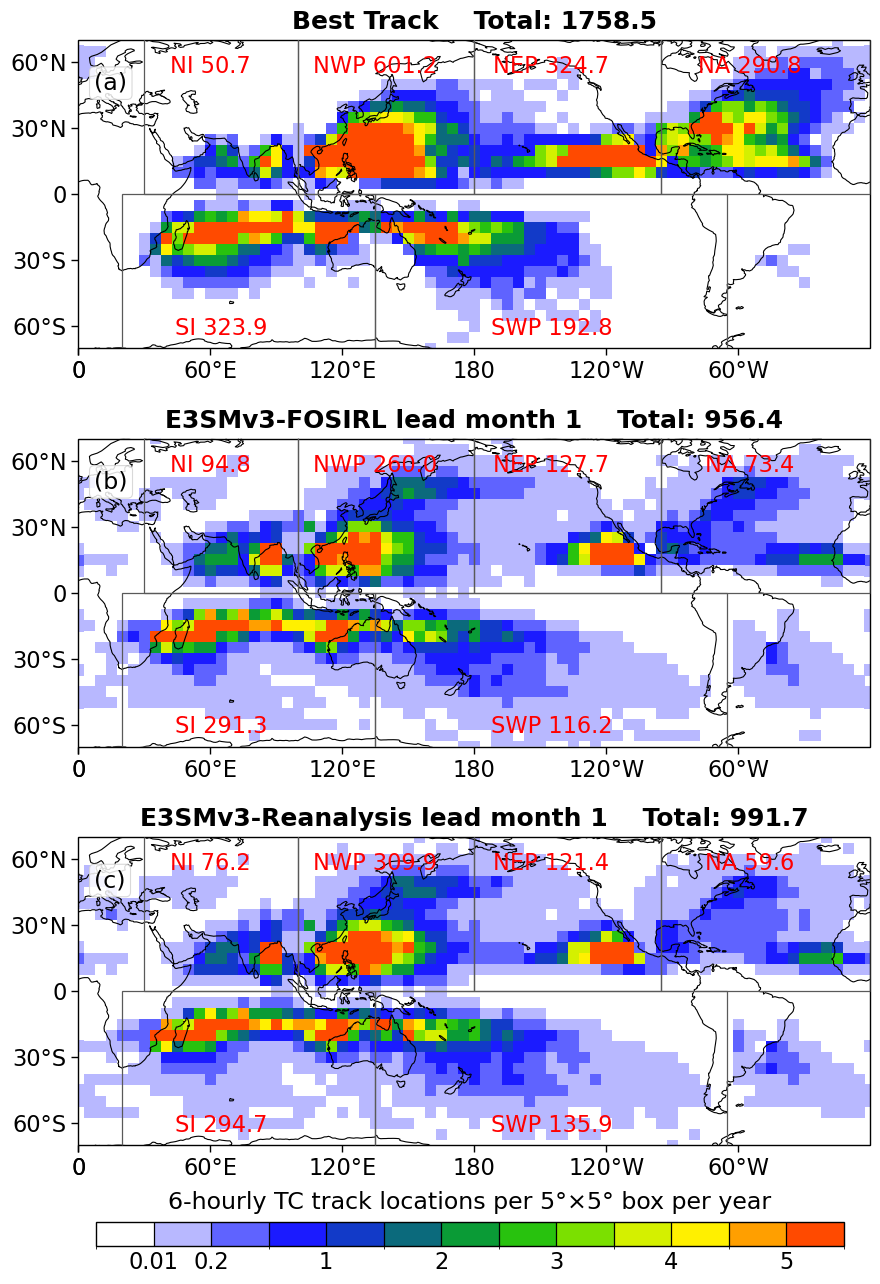

Annual-mean basin-integrated TC track-point density summary: 1980-2018, lead month 1


,lead,E3SMv3-FOSIRL,E3SMv3-Reanalysis,BestTrack,E3SMv3-FOSIRL/BestTrack,E3SMv3-Reanalysis/BestTrack
basin,,,,,,
NWP,1,181.256410,235.741026,490.948718,0.369196,0.480174
NA,1,53.256410,42.887179,245.615385,0.216828,0.174611
EP,1,114.112821,110.328205,280.794872,0.406392,0.392914
NI,1,75.220513,59.879487,28.846154,2.607644,2.075822
SI,1,276.617949,281.169231,291.948718,0.947488,0.963077
SP,1,102.171795,121.035897,180.820513,0.565045,0.669370


In [130]:
# ============================================================
# Compare annual global TC track density: Best Track vs E3SM
# ============================================================
#
# Definition:
#   TC track density = average number of 6-hourly TC track locations
#   within each DIAG_GRID_SIZE × DIAG_GRID_SIZE grid box per year.
#
# Annual global:
#   NH_JJASON + SH_DJFMAM, then averaged over years.
#
# For lead month 1:
#   May initialization      -> NH_JJASON
#   November initialization -> SH_DJFMAM
#
# Observations are masked to the same season-year pairs that have
# valid E3SM samples at the selected lead, so Best Track and E3SM
# are compared over the same target seasons.

import matplotlib.colors as mcolors
from matplotlib.patches import Rectangle

# ============================================================
# Load the two E3SM diagnostics used by this figure
# ============================================================

def _load_first_figure_case(case_key):
    spec = E3SM_HINDCASTS[case_key]
    expected_path = hindcast_diag_path(case_key)
    if (
        "DS_DIAG" in globals()
        and DS_DIAG.attrs.get("case_prefix") == spec["case_prefix"]
        and all(
            name in DS_DIAG
            for name in ["tc_track_density_count", "tc_storm_count", "sample_count"]
        )
    ):
        print(f"Using in-memory diagnostics for {spec['label']}.")
        return DS_DIAG
    if not expected_path.is_file():
        raise FileNotFoundError(
            f"Missing {spec['label']} TC diagnostic: {expected_path}\n"
            f"Set PROCESS_CASE_KEY={case_key!r} and run Sections 7-8 once to create it."
        )
    print(f"Loaded {spec['label']}: {expected_path}")
    return xr.open_dataset(expected_path)


PRIMARY_DIAG = _load_first_figure_case(PRIMARY_CASE_KEY)
REFERENCE_DIAG = _load_first_figure_case(REFERENCE_CASE_KEY)
OBS_DIAG = next(
    (ds for ds in [PRIMARY_DIAG, REFERENCE_DIAG] if "obs_track_density_count" in ds),
    None,
)
if OBS_DIAG is None:
    raise ValueError(
        "Neither E3SM cache contains the IBTrACS companion variables. "
        "Run Section 8 for either case."
    )

# ============================================================
# Year selection
# ============================================================

primary_years = PRIMARY_DIAG.year.astype(int).values
reference_years = REFERENCE_DIAG.year.astype(int).values
diag_years = np.intersect1d(primary_years, reference_years)
plot_years = np.intersect1d(REQUESTED_YEARS, diag_years)

if plot_years.size == 0:
    raise ValueError(
        f"No overlap between requested years {REQUESTED_YEARS[0]}-{REQUESTED_YEARS[-1]} "
        f"and the common E3SM diagnostic years."
    )

if plot_years[0] != REQUESTED_YEARS[0] or plot_years[-1] != REQUESTED_YEARS[-1]:
    print(
        f"Requested {REQUESTED_YEARS[0]}-{REQUESTED_YEARS[-1]}, "
        f"but common E3SM coverage is {diag_years.min()}-{diag_years.max()}; "
        f"plotting {plot_years[0]}-{plot_years[-1]} ({plot_years.size} years)."
    )

# ============================================================
# Select model and observation count/sample arrays
# ============================================================

model_count = PRIMARY_DIAG["tc_track_density_count"].sel(
    lead=PLOT_LEAD,
    year=plot_years,
    season=REQUIRED_SEASONS,
)

reference_count = REFERENCE_DIAG["tc_track_density_count"].sel(
    lead=PLOT_LEAD,
    year=plot_years,
    season=REQUIRED_SEASONS,
)

obs_count = OBS_DIAG["obs_track_density_count"].sel(
    year=plot_years,
    season=REQUIRED_SEASONS,
)

model_sample = PRIMARY_DIAG["sample_count"].sel(
    lead=PLOT_LEAD,
    year=plot_years,
    season=REQUIRED_SEASONS,
)

reference_sample = REFERENCE_DIAG["sample_count"].sel(
    lead=PLOT_LEAD,
    year=plot_years,
    season=REQUIRED_SEASONS,
)

obs_sample = OBS_DIAG["obs_sample_count"].sel(
    year=plot_years,
    season=REQUIRED_SEASONS,
)

model_storm_count = PRIMARY_DIAG["tc_storm_count"].sel(
    lead=PLOT_LEAD,
    year=plot_years,
    season=REQUIRED_SEASONS,
)

reference_storm_count = REFERENCE_DIAG["tc_storm_count"].sel(
    lead=PLOT_LEAD,
    year=plot_years,
    season=REQUIRED_SEASONS,
)

obs_storm_count = OBS_DIAG["obs_storm_count"].sel(
    year=plot_years,
    season=REQUIRED_SEASONS,
)

# ============================================================
# Apply model-valid season/year mask before model-vs-observation comparison
# ============================================================

model_valid_season_year = model_sample > 0
reference_valid_season_year = reference_sample > 0
valid_annual_year = (
    model_valid_season_year.all("season")
    & reference_valid_season_year.all("season")
)
valid_year_values = valid_annual_year.year.values[valid_annual_year.values]

if valid_year_values.size == 0:
    raise ValueError(
        f"No years have both {REQUIRED_SEASONS} sampled by both E3SM cases at lead {PLOT_LEAD}."
    )

if valid_year_values.size != plot_years.size:
    dropped = sorted(set(plot_years.tolist()) - set(valid_year_values.tolist()))
    print(
        f"Lead {PLOT_LEAD}: dropping years without both seasons sampled by both E3SM cases: {dropped}"
    )

plot_years = valid_year_values
model_count = model_count.sel(year=plot_years).where(model_valid_season_year.sel(year=plot_years))
reference_count = reference_count.sel(year=plot_years).where(reference_valid_season_year.sel(year=plot_years))
comparison_valid_season_year = (
    model_valid_season_year.sel(year=plot_years)
    & reference_valid_season_year.sel(year=plot_years)
)
obs_count = obs_count.sel(year=plot_years).where(comparison_valid_season_year)
model_sample = model_sample.sel(year=plot_years)
reference_sample = reference_sample.sel(year=plot_years)
obs_sample = obs_sample.sel(year=plot_years).where(comparison_valid_season_year)
model_storm_count = model_storm_count.sel(year=plot_years).where(model_valid_season_year.sel(year=plot_years))
reference_storm_count = reference_storm_count.sel(year=plot_years).where(reference_valid_season_year.sel(year=plot_years))
obs_storm_count = obs_storm_count.sel(year=plot_years).where(comparison_valid_season_year)

# ============================================================
# Combine NH + SH into annual global TC-season count maps
# ============================================================

model_annual_count = model_count.sum("season", skipna=True, min_count=1)
reference_annual_count = reference_count.sum("season", skipna=True, min_count=1)
obs_annual_count = obs_count.sum("season", skipna=True, min_count=1)

model_annual_storm_count = model_storm_count.sum("season", skipna=True, min_count=1)
reference_annual_storm_count = reference_storm_count.sum("season", skipna=True, min_count=1)
obs_annual_storm_count = obs_storm_count.sum("season", skipna=True, min_count=1)

# NH_JJASON and SH_DJFMAM are two hemispheric pieces of the same
# annual global diagnostic, so the annual sample count should be
# the number of realizations, not the sum across seasons.
model_annual_sample = model_sample.where(model_valid_season_year.sel(year=plot_years)).min("season", skipna=True)
reference_annual_sample = reference_sample.where(reference_valid_season_year.sel(year=plot_years)).min("season", skipna=True)
obs_annual_sample = obs_sample.min("season", skipna=True)

# Warn if seasonal sample counts differ.
model_sample_spread = (
    model_sample.max("season", skipna=True)
    - model_sample.min("season", skipna=True)
)
reference_sample_spread = (
    reference_sample.max("season", skipna=True)
    - reference_sample.min("season", skipna=True)
)
obs_sample_spread = (
    obs_sample.max("season", skipna=True)
    - obs_sample.min("season", skipna=True)
)

if float(model_sample_spread.max()) != 0:
    print(
        "Warning: model NH and SH sample counts differ for at least one year. "
        "Using the smaller annual sample count."
    )

if float(reference_sample_spread.max()) != 0:
    print(
        "Warning: Reanalysis NH and SH sample counts differ for at least one year. "
        "Using the smaller annual sample count."
    )

if float(obs_sample_spread.max()) != 0:
    print(
        "Warning: obs NH and SH sample counts differ for at least one year. "
        "Using the smaller annual sample count."
    )

# ============================================================
# Normalize to annual density per realization/year
# ============================================================

model_annual_density = (
    model_annual_count / model_annual_sample.where(model_annual_sample > 0)
)

reference_annual_density = (
    reference_annual_count / reference_annual_sample.where(reference_annual_sample > 0)
)

obs_annual_density = (
    obs_annual_count / obs_annual_sample.where(obs_annual_sample > 0)
)

model_annual_storm_mean = (
    model_annual_storm_count / model_annual_sample.where(model_annual_sample > 0)
)

reference_annual_storm_mean = (
    reference_annual_storm_count / reference_annual_sample.where(reference_annual_sample > 0)
)

obs_annual_storm_mean = (
    obs_annual_storm_count / obs_annual_sample.where(obs_annual_sample > 0)
)

model_field = model_annual_density.mean("year", skipna=True)
reference_field = reference_annual_density.mean("year", skipna=True)
obs_field = obs_annual_density.mean("year", skipna=True)

model_total = float(model_field.sum(("lat", "lon"), skipna=True))
reference_total = float(reference_field.sum(("lat", "lon"), skipna=True))
obs_total = float(obs_field.sum(("lat", "lon"), skipna=True))

# ============================================================
# Diagnostics
# ============================================================

print(
    f"Lead {PLOT_LEAD} valid comparison years: "
    f"{int(plot_years[0])}-{int(plot_years[-1])} ({plot_years.size} years)."
)
print(
    f"Lead {PLOT_LEAD} annual sample count after common-cohort masking: "
    f"{MODEL_LABEL} mean={float(model_annual_sample.mean()):.1f}, "
    f"{REFERENCE_LABEL} mean={float(reference_annual_sample.mean()):.1f}, "
    f"Best Track mean={float(obs_annual_sample.mean()):.1f}."
)

print(
    f"\nAnnual global detected storm counts (NH_JJASON + SH_DJFMAM):\n"
    f"  {MODEL_LABEL} raw accumulated:       "
    f"{float(model_annual_storm_count.mean('year', skipna=True)):.1f}\n"
    f"  {MODEL_LABEL} per-realization mean:  "
    f"{float(model_annual_storm_mean.mean('year', skipna=True)):.1f}\n"
    f"  {REFERENCE_LABEL} raw accumulated:    "
    f"{float(reference_annual_storm_count.mean('year', skipna=True)):.1f}\n"
    f"  {REFERENCE_LABEL} per-realization mean: "
    f"{float(reference_annual_storm_mean.mean('year', skipna=True)):.1f}\n"
    f"  Best Track observed mean:         "
    f"{float(obs_annual_storm_mean.mean('year', skipna=True)):.1f}"
)

print(
    f"\nAnnual global TC track-density map totals "
    f"summed over all {DIAG_GRID_SIZE:g}°×{DIAG_GRID_SIZE:g} grid points:\n"
    f"  {MODEL_LABEL} raw accumulated:       "
    f"{float(model_annual_count.sum(('lat', 'lon'), skipna=True).mean('year')):.1f}\n"
    f"  {MODEL_LABEL} per-realization mean:  {model_total:.1f}\n"
    f"  {REFERENCE_LABEL} raw accumulated:    "
    f"{float(reference_annual_count.sum(('lat', 'lon'), skipna=True).mean('year')):.1f}\n"
    f"  {REFERENCE_LABEL} per-realization mean: {reference_total:.1f}\n"
    f"  Best Track observed mean:         {obs_total:.1f}\n"
    f"  Note: this is not an annual storm count; one storm can contribute to multiple grid points."
)

print("\nModel annual sample count summary:")
display(model_annual_sample.to_series().describe())

print("\nReanalysis annual sample count summary:")
display(reference_annual_sample.to_series().describe())

print("\nObs annual sample count summary:")
display(obs_annual_sample.to_series().describe())

# ============================================================
# Colormap
# ============================================================

cmap = mcolors.ListedColormap(COLORBAR_COLORS)
cmap.set_bad((1, 1, 1, 0))
norm = mcolors.BoundaryNorm(COLORBAR_BOUNDS, cmap.N)

# ============================================================
# Plot formatting helper
# ============================================================

def _add_basin_boxes_and_totals(ax, field):
    if not SHOW_BASIN_TOTALS:
        return

    for name, b in BASINS.items():
        rect = Rectangle(
            (b["lon1"], b["lat1"]),
            b["lon2"] - b["lon1"],
            b["lat2"] - b["lat1"],
            linewidth=BASIN_BOX_WIDTH,
            edgecolor="0.35",
            facecolor="none",
            transform=ccrs.PlateCarree(),
            zorder=5,
        )
        ax.add_patch(rect)

        basin_sum = float(
            field
            .sel(
                lon=slice(b["lon1"], b["lon2"]),
                lat=slice(b["lat1"], b["lat2"]),
            )
            .sum(skipna=True)
        )

        ax.text(
            b["text_xy"][0],
            b["text_xy"][1],
            f"{name} {basin_sum:.1f}",
            color="red",
            fontsize=BASIN_LABEL_FONTSIZE,
            ha="center",
            va="center",
            transform=ccrs.PlateCarree(),
            zorder=6,
        )


def _format_tc_density_axis(ax, title, panel_label, field):
    ax.set_extent(MAP_EXTENT, crs=ccrs.PlateCarree())
    ax.set_title(title, fontsize=TITLE_FONTSIZE, fontweight="bold", pad=TITLE_PAD)
    ax.set_xlabel("")
    ax.set_ylabel("")

    ax.set_xticks(XTICKS, crs=ccrs.PlateCarree())
    ax.set_xticklabels(XTICK_LABELS, fontsize=TICK_FONTSIZE)

    ax.set_yticks(YTICKS, crs=ccrs.PlateCarree())
    ax.set_yticklabels(YTICK_LABELS, fontsize=TICK_FONTSIZE)

    ax.tick_params(
        axis="both",
        which="major",
        direction="out",
        length=TICK_LENGTH,
        width=TICK_WIDTH,
        top=False,
        right=False,
        labeltop=False,
        labelright=False,
    )

    for spine in ax.spines.values():
        spine.set_linewidth(SPINE_WIDTH)

    ax.coastlines(linewidth=COASTLINE_WIDTH, color="black")
    _add_basin_boxes_and_totals(ax, field)

    ax.text(
        PANEL_LABEL_XY[0],
        PANEL_LABEL_XY[1],
        panel_label,
        transform=ax.transAxes,
        fontsize=PANEL_LABEL_FONTSIZE,
        ha="left",
        va="center",
        bbox=PANEL_LABEL_BBOX,
        zorder=10,
    )

# ============================================================
# Plot Best Track, E3SMv3-FOSIRL, and E3SMv3-Reanalysis
# ============================================================

fig, axes = plt.subplots(
    PLOT_NROWS,
    PLOT_NCOLS,
    figsize=FIGSIZE,
    subplot_kw={"projection": ccrs.PlateCarree(central_longitude=CENTRAL_LONGITUDE)},
)
axes = np.asarray(axes).ravel()

plot_items = [
    (
        obs_field,
        obs_field.where(obs_field >= MIN_PLOT_VALUE),
        f"{OBS_LABEL}    Total: {obs_total:.1f}",
        "(a)",
    ),
    (
        model_field,
        model_field.where(model_field >= MIN_PLOT_VALUE),
        f"{MODEL_LABEL} lead month {PLOT_LEAD}    Total: {model_total:.1f}",
        "(b)",
    ),
    (
        reference_field,
        reference_field.where(reference_field >= MIN_PLOT_VALUE),
        f"{REFERENCE_LABEL} lead month {PLOT_LEAD}    Total: {reference_total:.1f}",
        "(c)",
    ),
]

im = None
for ax, (raw_field, plot_field, title, panel_label) in zip(axes, plot_items):
    im = plot_field.plot(
        ax=ax,
        transform=ccrs.PlateCarree(),
        cmap=cmap,
        norm=norm,
        add_colorbar=False,
    )
    _format_tc_density_axis(ax, title, panel_label, raw_field)

# Shared bottom boxed colorbar, placed in a dedicated axis so it does not
# overlap the lower map panel.
cbar_ax = fig.add_axes(COLORBAR_AX_POSITION)
cbar = fig.colorbar(
    im,
    cax=cbar_ax,
    orientation="horizontal",
    boundaries=COLORBAR_BOUNDS,
    ticks=COLORBAR_TICKS,
    spacing="uniform",
    drawedges=True,
)

cbar.ax.set_title(DENSITY_LABEL, fontsize=COLORBAR_TITLE_FONTSIZE, pad=COLORBAR_TITLE_PAD)
cbar.ax.set_xticklabels(COLORBAR_TICK_LABELS, fontsize=COLORBAR_TICK_FONTSIZE)
cbar.ax.tick_params(length=0)

cbar.outline.set_linewidth(COLORBAR_OUTLINE_WIDTH)
if hasattr(cbar, "dividers"):
    cbar.dividers.set_color("black")
    cbar.dividers.set_linewidth(COLORBAR_DIVIDER_WIDTH)

fig.subplots_adjust(**SUBPLOT_ADJUST)
plt.show()

# ============================================================
# Basin-integrated annual mean TC track density
# ============================================================

model_basin_count = PRIMARY_DIAG["tc_basin_track_density_count"].sel(
    lead=PLOT_LEAD,
    year=plot_years,
    season=REQUIRED_SEASONS,
)

reference_basin_count = REFERENCE_DIAG["tc_basin_track_density_count"].sel(
    lead=PLOT_LEAD,
    year=plot_years,
    season=REQUIRED_SEASONS,
)

obs_basin_count = OBS_DIAG["obs_basin_track_density_count"].sel(
    year=plot_years,
    season=REQUIRED_SEASONS,
)

model_basin_count = model_basin_count.where(model_valid_season_year.sel(year=plot_years))
reference_basin_count = reference_basin_count.where(reference_valid_season_year.sel(year=plot_years))
obs_basin_count = obs_basin_count.where(comparison_valid_season_year)

model_basin_annual_count = model_basin_count.sum("season", skipna=True, min_count=1)
reference_basin_annual_count = reference_basin_count.sum("season", skipna=True, min_count=1)
obs_basin_annual_count = obs_basin_count.sum("season", skipna=True, min_count=1)

model_basin_annual_density = (
    model_basin_annual_count / model_annual_sample.where(model_annual_sample > 0)
)

reference_basin_annual_density = (
    reference_basin_annual_count / reference_annual_sample.where(reference_annual_sample > 0)
)

obs_basin_annual_density = (
    obs_basin_annual_count / obs_annual_sample.where(obs_annual_sample > 0)
)

basin_summary = xr.Dataset(
    {
        MODEL_LABEL: model_basin_annual_density.mean("year", skipna=True),
        REFERENCE_LABEL: reference_basin_annual_density.mean("year", skipna=True),
        "BestTrack": obs_basin_annual_density.mean("year", skipna=True),
    }
).to_dataframe()

basin_summary = basin_summary[
    (basin_summary[MODEL_LABEL] != 0)
    | (basin_summary[REFERENCE_LABEL] != 0)
    | (basin_summary["BestTrack"] != 0)
].copy()

basin_summary[f"{MODEL_LABEL}/BestTrack"] = (
    basin_summary[MODEL_LABEL] / basin_summary["BestTrack"]
)
basin_summary[f"{REFERENCE_LABEL}/BestTrack"] = (
    basin_summary[REFERENCE_LABEL] / basin_summary["BestTrack"]
)

print(
    f"Annual-mean basin-integrated TC track-point density summary: "
    f"{plot_years[0]}-{plot_years[-1]}, lead month {PLOT_LEAD}"
)

display(basin_summary)

## 9. ENSO regression diagnostics

This block follows Yeager et al. Fig. 14: regress seasonal-mean TC track density on the corresponding seasonal-mean Niño-3.4 index, using JJASON in the Northern Hemisphere and DJFMAM in the Southern Hemisphere. The figure compares E3SMv3-FOSIRL and E3SMv3-Reanalysis against one shared Best Track panel. By default, it shows the full regression slope fields and overlays 90% significant cells; set `PLOT_SIGNIFICANT_ONLY = True` only when you want a strict Yeager-caption mask.

The original Yeager et al. panel uses 1971-2018.  This notebook uses the configured diagnostic window (`years`-`yeare`; currently 1980-2018) unless you regenerate `DS_DIAG` for a longer period.  At 19-month lead, the final target season may be partial when the forecast files are only 24 months long: November starts contribute JJASO rather than JJASON, and May starts contribute DJFMA rather than DJFMAM.

For archives with only May/November starts, the available Yeager-style seasonal leads are `1, 7, 13, 19`; the plotting cell automatically drops leads with no model samples.

Set `NINO_FILE` to your Niño index NetCDF.  A monthly Niño-3.4 file is preferred so the code can average JJASON for `NH_JJASON` and DJFMAM for `SH_DJFMAM`; yearly input is accepted as a fallback.


In [131]:
# Build the default HadISST2 index directly if absent. Custom index files
# must be supplied by the user; they are never overwritten by this processor.
_default_nino_name = "HadISST2_sst_Nino3.4SST_mon.nc"
if not NINO_FILE.is_file() or (TC_INPUT_MODE == "rebuild" and NINO_FILE.name == _default_nino_name):
    if TC_INPUT_MODE == "require" or NINO_FILE.name != _default_nino_name:
        raise FileNotFoundError(f"Required Niño index is missing: {NINO_FILE}")
    subprocess.run([
        sys.executable, str(REPO_ROOT / "scripts" / "run_process_sst_index.py"),
        "--sources", "obs", "--regions", "Nino3.4",
        "--obs-outdir", str(NINO_FILE.parent),
        *(["--force"] if TC_INPUT_MODE == "rebuild" else []),
    ], check=True, cwd=str(REPO_ROOT))
    if not NINO_FILE.is_file():
        raise RuntimeError(f"SST processor did not produce {NINO_FILE}")

from scipy.stats import t as student_t


def _guess_nino_var(ds: xr.Dataset) -> str:
    """Pick a likely Niño variable if NINO_VAR is not set."""
    preferred = ["nino34_ann", "nino34", "nino", "nino34_index", "oni"]
    for name in preferred:
        if name in ds.data_vars:
            return name
    one_dim = [name for name, da in ds.data_vars.items() if da.ndim == 1]
    if len(one_dim) == 1:
        return one_dim[0]
    raise ValueError(
        "Could not infer Niño variable. Set NINO_VAR to one of: "
        + ", ".join(ds.data_vars)
    )


def load_seasonal_nino_index(
    path: Path,
    varname: str | None = None,
    clim_years: tuple[int, int] | None = None,
) -> xr.DataArray:
    """Load Niño index as DataArray(season, year), averaged over TC seasons."""
    if not path.is_file():
        raise FileNotFoundError(f"Niño index file not found: {path}")
    ds = xr.open_dataset(path)
    varname = varname or _guess_nino_var(ds)
    da = ds[varname]

    if "time" not in da.dims and "year" not in da.dims:
        dim = da.dims[0]
        coord = da[dim].values if dim in da.coords else np.arange(da.sizes[dim])
        if np.issubdtype(np.asarray(coord).dtype, np.datetime64):
            da = da.rename({dim: "time"}).assign_coords(time=coord)
        else:
            da = da.assign_coords(year=(dim, coord.astype(int))).swap_dims({dim: "year"}).drop_vars(dim, errors="ignore")

    extra_dims = [d for d in da.dims if d not in ("time", "year")]
    if extra_dims:
        da = da.mean(extra_dims)

    if "time" in da.dims:
        # Keep xarray's datetime accessor so both numpy datetime64 and
        # cftime calendars (used by HadISST2 here) are supported.
        month = da["time"].dt.month.values.astype(int)
        year = da["time"].dt.year.values.astype(int)

        if clim_years is not None:
            clim_start, clim_end = clim_years
            clim_mask = (year >= clim_start) & (year <= clim_end)
            if not np.any(clim_mask):
                raise ValueError(
                    f"No Niño data fall within climatology years {clim_start}-{clim_end}."
                )
            monthly_clim = da.isel(time=clim_mask).groupby("time.month").mean("time")
            da = da.groupby("time.month") - monthly_clim
            print(f"Removed {clim_start}-{clim_end} monthly Niño-3.4 climatology.")

        nh_mask = np.isin(month, [6, 7, 8, 9, 10, 11])

        nh = (
            da.isel(time=nh_mask)
            .assign_coords(year=("time", year[nh_mask]))
            .groupby("year")
            .mean("time")
        )

        sh_mask = np.isin(month, [12, 1, 2, 3, 4, 5])
        sh_year = np.where(month == 12, year, year - 1)
        sh = (
            da.isel(time=sh_mask)
            .assign_coords(year=("time", sh_year[sh_mask]))
            .groupby("year")
            .mean("time")
        )

        season_coord = xr.DataArray(season_names, dims="season", name="season")
        nino = xr.concat([nh, sh], dim=season_coord, join="outer")
    elif "year" in da.dims:
        yearly = da.rename({"year": "year"})
        season_coord = xr.DataArray(season_names, dims="season", name="season")
        nino = xr.concat([yearly, yearly], dim=season_coord, join="exact")
        print("Niño input is yearly; using the same yearly index for both TC seasons.")

    nino = nino.astype(float).sortby("year").transpose("season", "year")
    nino.name = "seasonal_nino34_index"
    nino.attrs.update({
        "source_file": str(path),
        "source_variable": varname,
        "monthly_climatology": (
            f"{clim_years[0]}-{clim_years[1]}" if clim_years is not None else "not removed"
        ),
    })
    return nino


def regression_tcrit(n: xr.DataArray, confidence: float = SIG_CONFIDENCE) -> xr.DataArray:
    """Two-sided Student-t threshold for correlation/slope significance."""
    alpha = 1.0 - confidence
    return xr.apply_ufunc(
        lambda n_: student_t.ppf(1.0 - alpha / 2.0, np.maximum(n_ - 2, 1)),
        n.astype(float),
        vectorize=True,
        dask="allowed",
    ).where(n >= 3)


def xr_regress_y_on_x(y: xr.DataArray, x: xr.DataArray, sample_dim: str = "year") -> xr.Dataset:
    """
    Regress y against x along sample_dim.

    Returns slope, intercept, correlation, t-value for correlation/slope, and n.
    The t-value is r * sqrt((n - 2) / (1 - r**2)).
    """
    x, y = xr.align(x, y, join="inner")
    valid = np.isfinite(x) & np.isfinite(y)

    n = valid.sum(sample_dim)
    x_valid = x.where(valid)
    y_valid = y.where(valid)

    x_mean = x_valid.mean(sample_dim, skipna=True)
    y_mean = y_valid.mean(sample_dim, skipna=True)
    x_anom = x_valid - x_mean
    y_anom = y_valid - y_mean

    cov_xy = (x_anom * y_anom).sum(sample_dim, skipna=True)
    var_x = (x_anom ** 2).sum(sample_dim, skipna=True)
    var_y = (y_anom ** 2).sum(sample_dim, skipna=True)

    slope = (cov_xy / var_x).where(n >= 3)
    intercept = (y_mean - slope * x_mean).where(n >= 3)
    corr = cov_xy / np.sqrt(var_x * var_y)
    corr = corr.where(n >= 3)

    tval = corr * np.sqrt((n - 2) / (1 - corr ** 2))
    tval = tval.where(n >= 3)

    return xr.Dataset({
        "slope": slope,
        "intercept": intercept,
        "corr": corr,
        "tval": tval,
        "n": n,
    })


if NINO_FILE is None:
    print("Set NINO_FILE to your Niño-3.4 index NetCDF, then rerun this cell.")
else:
    if "DS_DIAG" not in globals():
        DIAG_OUT = OUTDIR / f"tc_lead_track_density_{case_prefix}_{PARSET}_{years}_{yeare}.nc"
        if not DIAG_OUT.exists():
            raise FileNotFoundError(f"Run the track-density diagnostic first; missing {DIAG_OUT}")
        DS_DIAG = xr.open_dataset(DIAG_OUT)
        print(f"Loaded existing track-density diagnostics: {DIAG_OUT}")

    nino_index = load_seasonal_nino_index(
        Path(NINO_FILE), NINO_VAR, clim_years=NINO_CLIM_YEARS
    )
    for required_var in ["tc_track_density_mean", "obs_track_density_mean"]:
        if required_var not in DS_DIAG:
            raise ValueError(
                f"DS_DIAG is missing {required_var!r}. Run the IBTrACS observed "
                "track-density companion block before regression."
            )

    analysis_years = np.asarray(
        [y for y in range(years, yeare + 1) if yexcl is None or y != yexcl],
        dtype=int,
    )
    diag_years = DS_DIAG.year.astype(int).values
    nino_years = nino_index.year.astype(int).values
    common_years = np.intersect1d(np.intersect1d(analysis_years, diag_years), nino_years)
    outside_analysis_years = np.setdiff1d(diag_years, analysis_years)
    missing_diag_years = np.setdiff1d(analysis_years, diag_years)
    missing_nino_years = np.setdiff1d(analysis_years, nino_years)

    if common_years.size < 3:
        raise ValueError(
            f"Need at least 3 overlapping years for regression; found {common_years.size}. "
            f"analysis years={analysis_years.min()}-{analysis_years.max()}, "
            f"DS_DIAG years={diag_years.min()}-{diag_years.max()}, "
            f"Niño years={nino_years.min()}-{nino_years.max()}"
        )
    print(f"Regression analysis years: {common_years.min()}-{common_years.max()} ({common_years.size} years)")
    if outside_analysis_years.size:
        print(f"Ignoring DS_DIAG years outside configured model window: {outside_analysis_years.tolist()}")
    if missing_diag_years.size:
        print(f"Configured model years missing from DS_DIAG: {missing_diag_years.tolist()}")
    if missing_nino_years.size:
        print(f"Configured model years missing from Niño index: {missing_nino_years.tolist()}")

    DS_DIAG_REG = DS_DIAG.sel(year=common_years)
    nino_index = nino_index.sel(year=common_years)
    print(nino_index)

    model_density_for_regression = DS_DIAG_REG["tc_track_density_mean"]
    if "sample_count" in DS_DIAG_REG:
        model_density_for_regression = model_density_for_regression.where(DS_DIAG_REG["sample_count"] > 0)
        empty_samples = (DS_DIAG_REG["sample_count"].sum("year") == 0)
        if bool(empty_samples.any()):
            empty_labels = [
                f"{str(season)} lead {int(lead)}"
                for season in empty_samples.season.values
                for lead in empty_samples.lead.values
                if bool(empty_samples.sel(season=season, lead=lead))
            ]
            print("No model samples for: " + ", ".join(empty_labels))

    reg_model = xr_regress_y_on_x(model_density_for_regression, nino_index)
    reg_obs = xr_regress_y_on_x(DS_DIAG_REG["obs_track_density_mean"], nino_index)

    model_tcrit = regression_tcrit(reg_model["n"])
    obs_tcrit = regression_tcrit(reg_obs["n"])

    # Rename variables to clear model/obs names in one output dataset.
    DS_REG = xr.Dataset({
        "model_slope": reg_model["slope"],
        "model_intercept": reg_model["intercept"],
        "model_corr": reg_model["corr"],
        "model_tval": reg_model["tval"],
        "model_n": reg_model["n"],
        "model_sample_count": DS_DIAG_REG["sample_count"] if "sample_count" in DS_DIAG_REG else reg_model["n"],
        "obs_slope": reg_obs["slope"],
        "obs_intercept": reg_obs["intercept"],
        "obs_corr": reg_obs["corr"],
        "obs_tval": reg_obs["tval"],
        "obs_n": reg_obs["n"],
        "model_tcrit_90": model_tcrit,
        "obs_tcrit_90": obs_tcrit,
        "model_slope_sig": reg_model["slope"].where(np.abs(reg_model["tval"]) >= model_tcrit, 0.0),
        "obs_slope_sig": reg_obs["slope"].where(np.abs(reg_obs["tval"]) >= obs_tcrit, 0.0),
        "nino_index": nino_index,
    })


    DS_REG.attrs.update({
        "description": "Regression of TC-season track-density diagnostics against Niño-3.4 averaged over the corresponding TC season.",
        "nino_file": str(NINO_FILE),
        "nino_variable": nino_index.attrs.get("source_variable", "unknown"),
        "significance_confidence_level": SIG_CONFIDENCE,
        "significance_test": "two-sided Student-t test using n - 2 degrees of freedom",
        "sample_mask": "Model regression masks tc_track_density_mean where sample_count <= 0.",
        "density_file": str(DIAG_OUT),
    })

    REG_OUT = OUTDIR / f"tc_lead_track_density_enso_regression_{case_prefix}_{PARSET}_{years}_{yeare}_{REG_NINO_LABEL}.nc"
    write_netcdf(DS_REG, REG_OUT)
    print(f"Saved regression diagnostics: {REG_OUT}")
    print(DS_REG)


Removed 1981-2010 monthly Niño-3.4 climatology.
Regression analysis years: 1980-2018 (39 years)
<xarray.DataArray 'seasonal_nino34_index' (season: 2, year: 39)> Size: 624B
array([[-0.08056809, -0.35642096,  1.21362606, -0.4101526 , -0.5727859 ,
        -0.55701581,  0.43863109,  1.35016456, -1.53030166, -0.40813179,
         0.17914178,  0.79227678,  0.09038933,  0.23505355,  0.62820927,
        -0.56082804, -0.32523694,  1.95953179, -1.07598089, -1.17124642,
        -0.58361934, -0.0949588 ,  1.0795052 ,  0.27014144,  0.65050986,
        -0.08993137,  0.48830146, -0.86598209, -0.28495322,  0.78664567,
        -1.274582  , -0.67851972,  0.33303954, -0.21871529,  0.31739784,
         2.02345322, -0.4505316 , -0.18231881,  0.50192209],
       [-0.39540519,  0.14986223,  1.66312017, -0.56336783, -0.98112486,
        -0.4572927 ,  0.9645167 ,  0.15351291, -1.36779036,  0.11203534,
         0.32699834,  1.54262998,  0.42516897,  0.22294693,  0.65597818,
        -0.6216701 , -0.12707631,  1.

Loaded E3SMv3-FOSIRL regression: /global/cfs/cdirs/e3sm/S2S2D/s2d_diag/JRA55_FOSIRL/tc_track/tc_lead_track_density_enso_regression_WCYCL20TR_ne30pg2_r05_IcoswISC30E3r5_JRA55_FOSIRL_set3_1980_2018_hadisst2.nc
Loaded E3SMv3-Reanalysis regression: /global/cfs/cdirs/e3sm/S2S2D/s2d_diag/Reanalysis/tc_track/tc_lead_track_density_enso_regression_WCYCL20TR_ne30pg2_r05_IcoswISC30E3r5_BruteForce_set3_1980_2018_hadisst2.nc
Plotting leads available for both E3SM cases: [1, 7, 13, 19]
Saved ENSO-TC regression plot: /global/cfs/cdirs/e3sm/www/zhan391/esp-lab_diag/fig_tc_track_density_enso_regression_fosirl_reanalysis.png


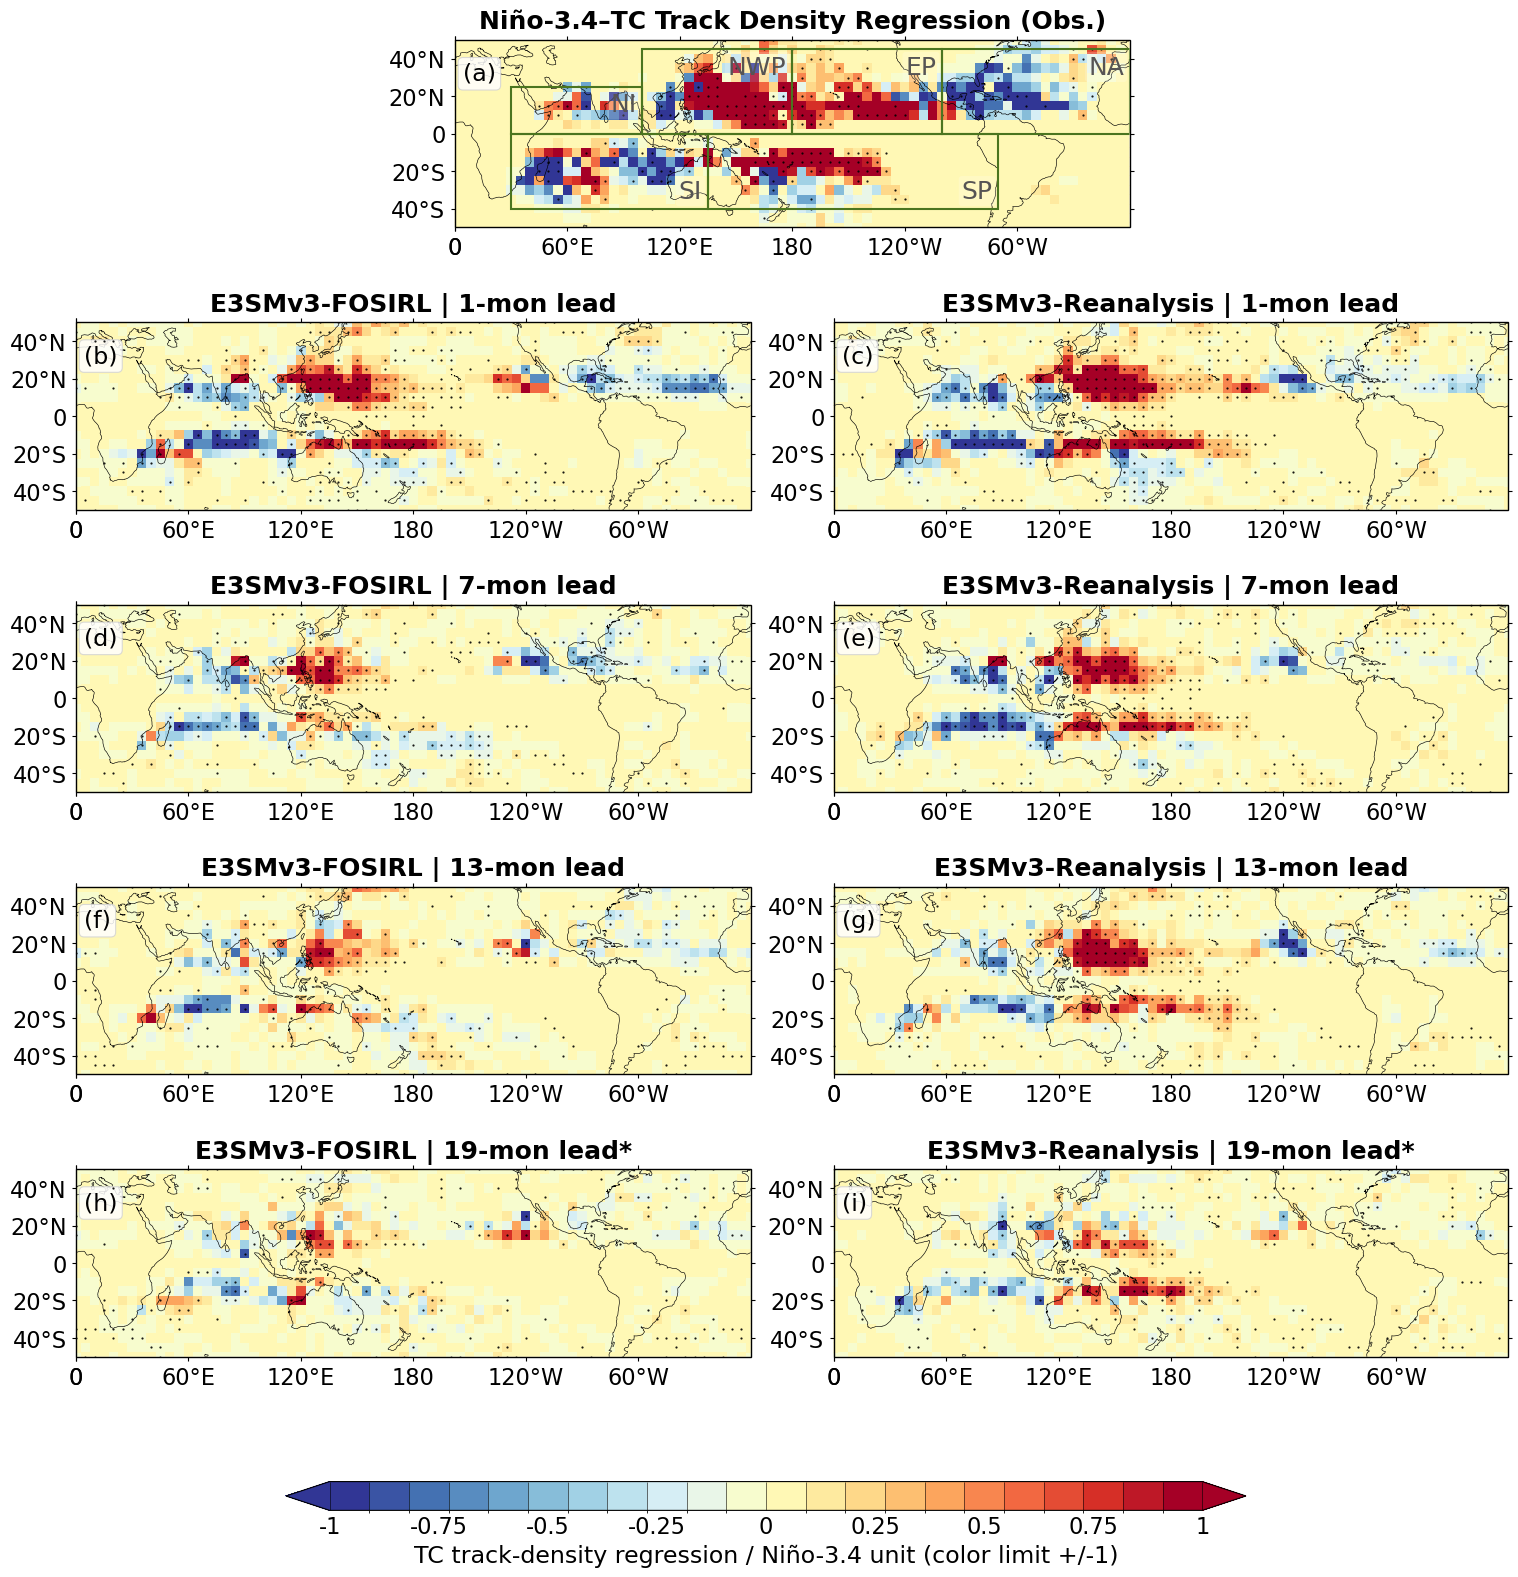

In [132]:
# Yeager-style Fig. 14 regression panel: BestTrack plus E3SM lead months.
# Default: plot the full regression slope field so weak model responses remain visible,
# and overlay small black markers where cells pass the 90% two-sided significance test.
# Set PLOT_SIGNIFICANT_ONLY=True to reproduce a strict significant-shading-only view.
# At 19-month lead, available 24-month forecasts may represent JJASO/DJFMA partial target seasons.
import matplotlib.colors as mcolors

def regression_diag_path(case_key):
    spec = E3SM_HINDCASTS[case_key]
    return (
        E3SMLE_OUTDIR / case_key / "tc_track"
        / (
            f"tc_lead_track_density_enso_regression_{spec['case_prefix']}_"
            f"{PARSET}_{years}_{yeare}_{REG_NINO_LABEL}.nc"
        )
    )


DS_REG_BY_CASE = {}
for regression_case_key in REGRESSION_CASE_KEYS:
    regression_path = regression_diag_path(regression_case_key)
    if not regression_path.is_file():
        raise FileNotFoundError(
            f"Missing {E3SM_HINDCASTS[regression_case_key]['label']} regression "
            f"diagnostic: {regression_path}. Set PROCESS_CASE_KEY="
            f"{regression_case_key!r} and run the regression cell once."
        )
    DS_REG_BY_CASE[regression_case_key] = xr.open_dataset(regression_path)
    print(
        f"Loaded {E3SM_HINDCASTS[regression_case_key]['label']} regression: "
        f"{regression_path}"
    )

# Backward-compatible alias for configuration checks below.
DS_REG = DS_REG_BY_CASE[REGRESSION_CASE_KEYS[0]]

FIGDIR = FIGURE_OUTDIR
FIGDIR.mkdir(parents=True, exist_ok=True)

available_leads_by_case = {}
for regression_case_key, regression_ds in DS_REG_BY_CASE.items():
    if "model_sample_count" in regression_ds:
        sample_by_lead = regression_ds["model_sample_count"].sum(
            ("season", "year"), skipna=True
        )
        available_leads_by_case[regression_case_key] = {
            int(lead) for lead in regression_ds.lead.values
            if float(sample_by_lead.sel(lead=lead)) > 0
        }
    else:
        available_leads_by_case[regression_case_key] = {int(lead) for lead in LEADS}
common_available_leads = set.intersection(*available_leads_by_case.values())
PLOT_LEADS = [lead for lead in PLOT_LEADS_REQUESTED if lead in common_available_leads]
if not PLOT_LEADS:
    raise ValueError("No requested model leads with positive sample count are available for plotting.")
missing_requested_leads = [lead for lead in PLOT_LEADS_REQUESTED if lead not in PLOT_LEADS]
if missing_requested_leads:
    print(f"Requested leads not available and skipped: {missing_requested_leads}")
print(f"Plotting leads available for both E3SM cases: {PLOT_LEADS}")

# Global TC-season map: NH_JJASON for Northern Hemisphere basins and
# SH_DJFMAM for Southern Hemisphere basins, matching the NCL Fig. 14 layout.
obs_regression_ds = DS_REG_BY_CASE[REGRESSION_CASE_KEYS[0]]
obs_map = obs_regression_ds["obs_slope"].sum("season", skipna=True, min_count=1)
obs_sig = obs_regression_ds["obs_slope_sig"].sum("season", skipna=True, min_count=1) != 0
model_maps_by_case = {
    regression_case_key: [
        regression_ds["model_slope"].sel(lead=lead).sum("season", skipna=True, min_count=1)
        for lead in PLOT_LEADS
    ]
    for regression_case_key, regression_ds in DS_REG_BY_CASE.items()
}
model_sigs_by_case = {
    regression_case_key: [
        regression_ds["model_slope_sig"].sel(lead=lead).sum("season", skipna=True, min_count=1) != 0
        for lead in PLOT_LEADS
    ]
    for regression_case_key, regression_ds in DS_REG_BY_CASE.items()
}

if PLOT_SIGNIFICANT_ONLY:
    obs_map = obs_map.where(obs_sig)
    model_maps_by_case = {
        key: [field.where(sig) for field, sig in zip(model_maps_by_case[key], model_sigs_by_case[key])]
        for key in REGRESSION_CASE_KEYS
    }
    PLOT_SIGNIFICANCE_MARKERS = False

if COLOR_LIMIT_MODE == "yeager":
    color_limit = float(COLOR_LIMIT)
else:
    all_model_maps = [
        field for key in REGRESSION_CASE_KEYS for field in model_maps_by_case[key]
    ]
    model_values = np.concatenate([
        np.ravel(np.asarray(field.values, dtype=float))
        for field in all_model_maps
        if np.isfinite(field.values).any()
    ])
    model_values = np.abs(model_values[np.isfinite(model_values)])
    if model_values.size:
        color_limit = max(COLOR_LIMIT_MIN, float(np.nanpercentile(model_values, COLOR_LIMIT_PERCENTILE)))
        color_limit = np.ceil(color_limit * 10.0) / 10.0
    else:
        color_limit = float(COLOR_LIMIT)
LEVELS = np.linspace(-color_limit, color_limit, N_COLOR_INTERVALS + 1)
TICKS = np.linspace(-color_limit, color_limit, N_COLORBAR_TICKS)
cmap = plt.get_cmap(COLORMAP_NAME).copy()
cmap.set_bad((1, 1, 1, 0))

def _lon_label(x):
    x = int(x) % 360
    if x == 0:
        return "0"
    if x == 180:
        return "180"
    return f"{x}°E" if x < 180 else f"{360 - x}°W"

def _lat_label(y):
    y = int(y)
    if y == 0:
        return "0"
    return f"{abs(y)}°N" if y > 0 else f"{abs(y)}°S"

def _coord_edges(coord):
    coord = np.asarray(coord, dtype=float)
    mids = 0.5 * (coord[:-1] + coord[1:])
    first = coord[0] - 0.5 * (coord[1] - coord[0])
    last = coord[-1] + 0.5 * (coord[-1] - coord[-2])
    return np.concatenate([[first], mids, [last]])

def _field_for_pcolormesh(field):
    field = field.transpose("lat", "lon")
    lon = field["lon"].values
    lat = field["lat"].values
    return field.values, _coord_edges(lon), _coord_edges(lat)

def _plot_sig_markers(ax, sig):
    if not PLOT_SIGNIFICANCE_MARKERS:
        return
    sig = sig.transpose("lat", "lon")
    sig_values = sig.values.astype(bool)
    if PLOT_MARKER_STRIDE > 1:
        keep = np.zeros_like(sig_values, dtype=bool)
        keep[::PLOT_MARKER_STRIDE, ::PLOT_MARKER_STRIDE] = True
        sig_values &= keep
    yy, xx = np.where(sig_values)
    if yy.size == 0:
        return
    ax.scatter(
        sig["lon"].values[xx], sig["lat"].values[yy],
        s=SIG_MARKER_SIZE, marker=SIG_MARKER_STYLE, color=SIG_MARKER_COLOR, alpha=SIG_MARKER_ALPHA,
        linewidths=SIG_MARKER_LINEWIDTH, transform=ccrs.PlateCarree(), zorder=5,
    )

def _plot_regression_panel(ax, field, sig, title, panel_label, show_basin_boxes=False):
    data, lon_edges, lat_edges = _field_for_pcolormesh(field)
    has_data = np.isfinite(data).any()
    im = ax.pcolormesh(
        lon_edges, lat_edges, data,
        cmap=cmap,
        norm=mcolors.BoundaryNorm(LEVELS, cmap.N),
        transform=ccrs.PlateCarree(),
        shading="flat",
    )
    _plot_sig_markers(ax, sig)
    if not has_data:
        ax.text(
            0.5, 0.5, "no samples", transform=ax.transAxes,
            ha="center", va="center", fontsize=NO_SAMPLE_FONTSIZE, color="0.25",
            bbox=PANEL_LABEL_BBOX_REGRESSION,
            zorder=8,
        )
    ax.set_extent(MAP_EXTENT_REGRESSION, crs=ccrs.PlateCarree())
    ax.coastlines(linewidth=COASTLINE_WIDTH_REGRESSION, color="black")
    if SHOW_EQUATOR_LINE:
        ax.plot([0, 360], [0, 0], color="black", linewidth=EQUATOR_LINE_WIDTH, transform=ccrs.PlateCarree())
    ax.set_title(title, fontsize=TITLE_FONTSIZE_REGRESSION, fontweight="bold", pad=TITLE_PAD_REGRESSION)

    xticks = XTICKS_REGRESSION
    yticks = YTICKS_REGRESSION
    ax.set_xticks(xticks, crs=ccrs.PlateCarree())
    ax.set_xticklabels([_lon_label(x) for x in xticks], fontsize=TICK_FONTSIZE_REGRESSION)
    ax.set_yticks(yticks, crs=ccrs.PlateCarree())
    ax.set_yticklabels([_lat_label(y) for y in yticks], fontsize=TICK_FONTSIZE_REGRESSION)
    ax.tick_params(axis="both", which="major", direction="out", length=TICK_LENGTH_REGRESSION, width=TICK_WIDTH_REGRESSION,
                   top=True, right=True, labeltop=False, labelright=False)
    for spine in ax.spines.values():
        spine.set_linewidth(SPINE_WIDTH_REGRESSION)

    ax.text(
        PANEL_LABEL_XY_REGRESSION[0], PANEL_LABEL_XY_REGRESSION[1], panel_label, transform=ax.transAxes,
        fontsize=PANEL_LABEL_FONTSIZE_REGRESSION, ha="left", va="center",
        bbox=PANEL_LABEL_BBOX_REGRESSION,
    )

    if show_basin_boxes:
        import matplotlib.patches as mpatches
        for name, b in REGRESSION_BASINS.items():
            rect = mpatches.Rectangle(
                (b["lon1"], b["lat1"]),
                b["lon2"] - b["lon1"],
                b["lat2"] - b["lat1"],
                fill=False,
                linewidth=BASIN_BOX_LINEWIDTH_REGRESSION,
                edgecolor=BASIN_BOX_COLOR_REGRESSION,
                transform=ccrs.PlateCarree(),
                zorder=6,
            )
            ax.add_patch(rect)
            label_lon = b["lon2"] - BASIN_LABEL_LON_PAD_REGRESSION
            if b["lat2"] <= 0:
                label_lat = b["lat1"] + BASIN_LABEL_LAT_PAD_REGRESSION
                label_va = "bottom"
            else:
                label_lat = b["lat2"] - BASIN_LABEL_LAT_PAD_REGRESSION
                label_va = "top"
            ax.text(
                label_lon, label_lat, name,
                transform=ccrs.PlateCarree(),
                fontsize=BASIN_LABEL_FONTSIZE_REGRESSION, ha="right", va=label_va, color=BASIN_LABEL_COLOR_REGRESSION,
                bbox=BASIN_LABEL_BBOX_REGRESSION, zorder=7,
            )
    return im

n_panels = 1 + len(REGRESSION_CASE_KEYS) * len(PLOT_LEADS)
fig = plt.figure(figsize=FIGSIZE_REGRESSION)
gs = fig.add_gridspec(GRID_NROWS, GRID_NCOLS)

axes = [
    fig.add_subplot(
        gs[OBS_GRID_SLOT],
        projection=ccrs.PlateCarree(central_longitude=CENTRAL_LONGITUDE_REGRESSION),
    )
]
fields = [obs_map]
sigs = [obs_sig]
titles = ["Niño-3.4–TC Track Density Regression (Obs.)"]
for lead_index, lead in enumerate(PLOT_LEADS):
    row = lead_index + 1
    for case_col, regression_case_key in enumerate(REGRESSION_CASE_KEYS):
        col_slice = slice(0, 2) if case_col == 0 else slice(2, 4)
        axes.append(
            fig.add_subplot(
                gs[row, col_slice],
                projection=ccrs.PlateCarree(central_longitude=CENTRAL_LONGITUDE_REGRESSION),
            )
        )
        fields.append(model_maps_by_case[regression_case_key][lead_index])
        sigs.append(model_sigs_by_case[regression_case_key][lead_index])
        lead_suffix = "*" if lead == 19 else ""
        titles.append(
            f"{E3SM_HINDCASTS[regression_case_key]['label']} | "
            f"{lead}-mon lead{lead_suffix}"
        )

panel_labels = [f"({chr(97 + i)})" for i in range(n_panels)]
im = None
for idx, (ax, field, sig, title, panel_label) in enumerate(zip(axes, fields, sigs, titles, panel_labels)):
    im = _plot_regression_panel(
        ax, field, sig, title, panel_label,
        show_basin_boxes=(idx == 0),
    )

cbar_ax = fig.add_axes(COLORBAR_AX_POSITION_REGRESSION)
cbar = fig.colorbar(
    im, cax=cbar_ax, orientation="horizontal",
    ticks=TICKS, extend="both", drawedges=True,
)
cbar.ax.set_xticklabels([f"{tick:.2g}" for tick in TICKS])
cbar.ax.tick_params(labelsize=COLORBAR_TICK_FONTSIZE_REGRESSION, length=0)
cbar.set_label(f"TC track-density regression / Niño-3.4 unit (color limit +/-{color_limit:g})", fontsize=COLORBAR_LABEL_FONTSIZE_REGRESSION)
fig.subplots_adjust(**REGRESSION_SUBPLOT_ADJUST)
FIG_REG_OUT = FIGDIR / figure_filename(
    "tc_track_density", "enso_regression", "fosirl_reanalysis"
)
mov.save_figure(
    fig, FIG_REG_OUT,
    mode="tc",
    metric="track_density_enso_regression",
    title="FOSIRL and Reanalysis TC Track Density ENSO Regression",
    caption=(
        "IBTrACS ENSO regression with matched E3SMv3-FOSIRL and E3SMv3-Reanalysis "
        f"Niño-3.4 regression maps at leads {PLOT_LEADS}"
    ),
    dpi=200,
)
print(f"Saved ENSO-TC regression plot: {FIG_REG_OUT}")
plt.show()


## 10. Multi-E3SM hindcast lead-time statistics

Load every enabled E3SM diagnostic cache and tabulate global annual TC track-point density and detected storm counts across lead time. Each lead uses the intersection of valid verification years across all available hindcasts, with IBTrACS sampled on that same cohort. The table reports model values, observed references, biases, and model/observation ratios. Missing caches are reported and skipped. To generate one, set `PROCESS_CASE_KEY` in Configuration and rerun the processing and IBTrACS sections.


In [133]:
# ============================================================
# Multi-E3SM lead-time statistics from cached diagnostics
# ============================================================
import pandas as pd
from IPython.display import display

comparison_cfg = MULTI_E3SM_STATISTICS_CONFIG
comparison_datasets = {}
missing_comparison_caches = {}

for case_key in comparison_cfg["case_keys"]:
    path = hindcast_diag_path(case_key)
    if case_key == PROCESS_CASE_KEY and "DS_DIAG" in globals():
        dataset = DS_DIAG.load()
    elif path.is_file():
        dataset = xr.open_dataset(path).load()
    else:
        missing_comparison_caches[case_key] = path
        continue

    required_vars = {
        "tc_track_density_count", "tc_basin_track_density_count",
        "tc_storm_count", "sample_count"
    }
    missing_vars = required_vars.difference(dataset.data_vars)
    if missing_vars:
        print(f"Skipping {case_key}: cache lacks {sorted(missing_vars)}")
        continue
    comparison_datasets[case_key] = dataset

for case_key, path in missing_comparison_caches.items():
    print(
        f"Comparison cache missing for {case_key}: {path}. "
        f"Set PROCESS_CASE_KEY={case_key!r} and run Sections 7–8 to create it."
    )

if not comparison_datasets:
    raise FileNotFoundError("No enabled E3SM hindcast diagnostic caches are available.")

obs_source = next(
    (dataset for dataset in comparison_datasets.values() if "obs_track_density_count" in dataset),
    DS_DIAG if "DS_DIAG" in globals() and "obs_track_density_count" in DS_DIAG else None,
)
if obs_source is None:
    raise ValueError("No loaded diagnostic contains the IBTrACS companion variables. Run Section 8 first.")
if "obs_basin_track_density_count" not in obs_source:
    raise ValueError(
        "The IBTrACS companion cache lacks obs_basin_track_density_count. "
        "Rerun Section 8."
    )

required_seasons = comparison_cfg["required_seasons"]
common_leads = None
for dataset in comparison_datasets.values():
    leads_here = set(map(int, dataset.lead.values))
    common_leads = leads_here if common_leads is None else common_leads.intersection(leads_here)
common_leads = np.asarray(sorted(common_leads), dtype=int)
if common_leads.size == 0:
    raise ValueError("The available E3SM diagnostics have no common lead coordinates.")

comparison_rows = []
basin_comparison_rows = []
for lead in common_leads:
    valid_year_sets = []
    for dataset in comparison_datasets.values():
        samples = dataset["sample_count"].sel(lead=lead, season=required_seasons)
        valid = (samples > 0).all("season")
        valid_year_sets.append(set(map(int, valid.year.values[valid.values])))

    obs_samples = obs_source["obs_sample_count"].sel(season=required_seasons)
    obs_valid = (obs_samples > 0).all("season")
    valid_year_sets.append(set(map(int, obs_valid.year.values[obs_valid.values])))
    common_years = np.asarray(sorted(set.intersection(*valid_year_sets)), dtype=int)
    if common_years.size == 0:
        print(f"Skipping lead {lead}: no common valid verification years.")
        continue

    obs_sample = (
        obs_source["obs_sample_count"]
        .sel(year=common_years, season=required_seasons)
        .min("season")
    )
    obs_track = (
        obs_source["obs_track_density_count"]
        .sel(year=common_years, season=required_seasons)
        .sum("season", skipna=True, min_count=1)
        / obs_sample.where(obs_sample > 0)
    ).sum(("lat", "lon"), skipna=True).mean("year", skipna=True)
    obs_storm = (
        obs_source["obs_storm_count"]
        .sel(year=common_years, season=required_seasons)
        .sum("season", skipna=True, min_count=1)
        / obs_sample.where(obs_sample > 0)
    ).mean("year", skipna=True)
    obs_basin_track = (
        obs_source["obs_basin_track_density_count"]
        .sel(year=common_years, season=required_seasons)
        .sum("season", skipna=True, min_count=1)
        / obs_sample.where(obs_sample > 0)
    ).mean("year", skipna=True)

    for case_key, dataset in comparison_datasets.items():
        model_sample = (
            dataset["sample_count"]
            .sel(lead=lead, year=common_years, season=required_seasons)
            .min("season")
        )
        model_track = (
            dataset["tc_track_density_count"]
            .sel(lead=lead, year=common_years, season=required_seasons)
            .sum("season", skipna=True, min_count=1)
            / model_sample.where(model_sample > 0)
        ).sum(("lat", "lon"), skipna=True).mean("year", skipna=True)
        model_storm = (
            dataset["tc_storm_count"]
            .sel(lead=lead, year=common_years, season=required_seasons)
            .sum("season", skipna=True, min_count=1)
            / model_sample.where(model_sample > 0)
        ).mean("year", skipna=True)
        model_basin_track = (
            dataset["tc_basin_track_density_count"]
            .sel(lead=lead, year=common_years, season=required_seasons)
            .sum("season", skipna=True, min_count=1)
            / model_sample.where(model_sample > 0)
        ).mean("year", skipna=True)
        comparison_rows.append({
            "case": case_key,
            "lead": int(lead),
            "n_years": int(common_years.size),
            "year_start": int(common_years.min()),
            "year_end": int(common_years.max()),
            "track_density_total": float(model_track),
            "storm_count": float(model_storm),
            "obs_track_density_total": float(obs_track),
            "obs_storm_count": float(obs_storm),
        })
        common_basins = np.intersect1d(
            model_basin_track.basin.values, obs_basin_track.basin.values
        )
        for basin in common_basins:
            basin_comparison_rows.append({
                "case": case_key,
                "lead": int(lead),
                "basin": str(basin),
                "n_years": int(common_years.size),
                "year_start": int(common_years.min()),
                "year_end": int(common_years.max()),
                "track_density_total": float(model_basin_track.sel(basin=basin)),
                "obs_track_density_total": float(obs_basin_track.sel(basin=basin)),
            })

comparison_table = pd.DataFrame(comparison_rows)
if comparison_table.empty:
    raise ValueError("No common-cohort lead metrics could be computed.")
comparison_table["model"] = comparison_table["case"].map(
    {key: spec["label"] for key, spec in E3SM_HINDCASTS.items()}
)
comparison_table["track_density_bias"] = (
    comparison_table["track_density_total"]
    - comparison_table["obs_track_density_total"]
)
comparison_table["track_density_ratio"] = (
    comparison_table["track_density_total"]
    / comparison_table["obs_track_density_total"].replace(0, np.nan)
)
comparison_table["storm_count_bias"] = (
    comparison_table["storm_count"] - comparison_table["obs_storm_count"]
)
comparison_table["storm_count_ratio"] = (
    comparison_table["storm_count"]
    / comparison_table["obs_storm_count"].replace(0, np.nan)
)

table_columns = [
    "n_years", "year_start", "year_end",
    "track_density_total", "obs_track_density_total",
    "track_density_bias", "track_density_ratio",
    "storm_count", "obs_storm_count",
    "storm_count_bias", "storm_count_ratio",
]
comparison_table = (
    comparison_table
    .set_index(["lead", "model"])
    .sort_index()
    [table_columns]
)
comparison_table_display = comparison_table.copy()
float_columns = comparison_table_display.select_dtypes(include=["floating"]).columns
comparison_table_display[float_columns] = comparison_table_display[float_columns].round(3)
print(
    "Multi-E3SM global TC statistics on lead-specific common verification cohorts\n"
    "Bias = model - IBTrACS; ratio = model / IBTrACS."
)
display(comparison_table_display)

basin_table = pd.DataFrame(basin_comparison_rows)
if basin_table.empty:
    raise ValueError("No common-cohort basin statistics could be computed.")
basin_names = {name: spec["long_name"] for name, spec in BASIN_DEFS.items()}
basin_order = list(basin_names)
basin_table["model"] = basin_table["case"].map(
    {key: spec["label"] for key, spec in E3SM_HINDCASTS.items()}
)
basin_table["basin_name"] = basin_table["basin"].map(basin_names)
basin_table["track_density_bias"] = (
    basin_table["track_density_total"]
    - basin_table["obs_track_density_total"]
)
basin_table["track_density_ratio"] = (
    basin_table["track_density_total"]
    / basin_table["obs_track_density_total"].replace(0, np.nan)
)
basin_table["basin"] = pd.Categorical(
    basin_table["basin"], categories=basin_order, ordered=True
)
basin_table = (
    basin_table
    .sort_values(["lead", "basin", "model"])
    .set_index(["lead", "basin", "model"])
    [[
        "basin_name", "n_years", "year_start", "year_end",
        "track_density_total", "obs_track_density_total",
        "track_density_bias", "track_density_ratio",
    ]]
)
basin_table_display = basin_table.copy()
basin_float_columns = basin_table_display.select_dtypes(include=["floating"]).columns
basin_table_display[basin_float_columns] = (
    basin_table_display[basin_float_columns].round(3)
)
print(
    "\nBasin-integrated TC track-density statistics\n"
    "Bias = model - IBTrACS; ratio = model / IBTrACS."
)
display(basin_table_display)


Skipping lead 4: no common valid verification years.
Skipping lead 10: no common valid verification years.
Skipping lead 16: no common valid verification years.
Multi-E3SM global TC statistics on lead-specific common verification cohorts
Bias = model - IBTrACS; ratio = model / IBTrACS.


n_years  year_start  year_end  track_density_total  \
lead model                                                                   
1    E3SMv3-FOSIRL           39        1980      2018              956.390   
     E3SMv3-Reanalysis       39        1980      2018              991.692   
7    E3SMv3-FOSIRL           38        1981      2018              838.111   
     E3SMv3-Reanalysis       38        1981      2018              864.208   
13   E3SMv3-FOSIRL           38        1981      2018              955.945   
     E3SMv3-Reanalysis       38        1981      2018              880.816   
19   E3SMv3-FOSIRL           37        1982      2018              811.908   
     E3SMv3-Reanalysis       37        1982      2018              798.157   

                        obs_track_density_total  track_density_bias  \
lead model                                                            
1    E3SMv3-FOSIRL                     1758.487            -802.097   
     E3SMv3-Reanalysis                 1758.487            -766.795   
7    E3SMv3-FOSIRL                     1766.526            -928.416   
     E3SMv3-Reanalysis                 1766.526            -902.318   
13   E3SMv3-FOSIRL                     1766.526            -810.582   
     E3SMv3-Reanalysis                 1766.526            -885.711   
19   E3SMv3-FOSIRL                     1768.027            -956.119   
     E3SMv3-Reanalysis                 1768.027            -969.870   

                        track_density_ratio  storm_count  obs_storm_count  \
lead model                                                                  
1    E3SMv3-FOSIRL                    0.544       44.023           90.154   
     E3SMv3-Reanalysis                0.564       44.323           90.154   
7    E3SMv3-FOSIRL                    0.474       40.447           90.316   
     E3SMv3-Reanalysis                0.489       40.345           90.316   
13   E3SMv3-FOSIRL                    0.541       44.495           90.316   
     E3SMv3-Reanalysis                0.499       40.474           90.316   
19   E3SMv3-FOSIRL                    0.459       37.714           90.243   
     E3SMv3-Reanalysis                0.451       35.957           90.243   

                        storm_count_bias  storm_count_ratio  
lead model                                                   
1    E3SMv3-FOSIRL               -46.131              0.488  
     E3SMv3-Reanalysis           -45.831              0.492  
7    E3SMv3-FOSIRL               -49.868              0.448  
     E3SMv3-Reanalysis           -49.971              0.447  
13   E3SMv3-FOSIRL               -45.821              0.493  
     E3SMv3-Reanalysis           -49.842              0.448  
19   E3SMv3-FOSIRL               -52.530              0.418  
     E3SMv3-Reanalysis           -54.286              0.398


Basin-integrated TC track-density statistics
Bias = model - IBTrACS; ratio = model / IBTrACS.


basin_name  n_years  year_start  \
lead basin model                                                          
1    NWP   E3SMv3-FOSIRL      Northwestern Pacific       39        1980   
           E3SMv3-Reanalysis  Northwestern Pacific       39        1980   
     NA    E3SMv3-FOSIRL            North Atlantic       39        1980   
           E3SMv3-Reanalysis        North Atlantic       39        1980   
     EP    E3SMv3-FOSIRL           Eastern Pacific       39        1980   
           E3SMv3-Reanalysis       Eastern Pacific       39        1980   
     NI    E3SMv3-FOSIRL        North Indian Ocean       39        1980   
           E3SMv3-Reanalysis    North Indian Ocean       39        1980   
     SI    E3SMv3-FOSIRL        South Indian Ocean       39        1980   
           E3SMv3-Reanalysis    South Indian Ocean       39        1980   
     SP    E3SMv3-FOSIRL       South Pacific Ocean       39        1980   
           E3SMv3-Reanalysis   South Pacific Ocean       39        1980   
7    NWP   E3SMv3-FOSIRL      Northwestern Pacific       38        1981   
           E3SMv3-Reanalysis  Northwestern Pacific       38        1981   
     NA    E3SMv3-FOSIRL            North Atlantic       38        1981   
           E3SMv3-Reanalysis        North Atlantic       38        1981   
     EP    E3SMv3-FOSIRL           Eastern Pacific       38        1981   
           E3SMv3-Reanalysis       Eastern Pacific       38        1981   
     NI    E3SMv3-FOSIRL        North Indian Ocean       38        1981   
           E3SMv3-Reanalysis    North Indian Ocean       38        1981   
     SI    E3SMv3-FOSIRL        South Indian Ocean       38        1981   
           E3SMv3-Reanalysis    South Indian Ocean       38        1981   
     SP    E3SMv3-FOSIRL       South Pacific Ocean       38        1981   
           E3SMv3-Reanalysis   South Pacific Ocean       38        1981   
13   NWP   E3SMv3-FOSIRL      Northwestern Pacific       38        1981   
           E3SMv3-Reanalysis  Northwestern Pacific       38        1981   
     NA    E3SMv3-FOSIRL            North Atlantic       38        1981   
           E3SMv3-Reanalysis        North Atlantic       38        1981   
     EP    E3SMv3-FOSIRL           Eastern Pacific       38        1981   
           E3SMv3-Reanalysis       Eastern Pacific       38        1981   
     NI    E3SMv3-FOSIRL        North Indian Ocean       38        1981   
           E3SMv3-Reanalysis    North Indian Ocean       38        1981   
     SI    E3SMv3-FOSIRL        South Indian Ocean       38        1981   
           E3SMv3-Reanalysis    South Indian Ocean       38        1981   
     SP    E3SMv3-FOSIRL       South Pacific Ocean       38        1981   
           E3SMv3-Reanalysis   South Pacific Ocean       38        1981   
19   NWP   E3SMv3-FOSIRL      Northwestern Pacific       37        1982   
           E3SMv3-Reanalysis  Northwestern Pacific       37        1982   
     NA    E3SMv3-FOSIRL            North Atlantic       37        1982   
           E3SMv3-Reanalysis        North Atlantic       37        1982   
     EP    E3SMv3-FOSIRL           Eastern Pacific       37        1982   
           E3SMv3-Reanalysis       Eastern Pacific       37        1982   
     NI    E3SMv3-FOSIRL        North Indian Ocean       37        1982   
           E3SMv3-Reanalysis    North Indian Ocean       37        1982   
     SI    E3SMv3-FOSIRL        South Indian Ocean       37        1982   
           E3SMv3-Reanalysis    South Indian Ocean       37        1982   
     SP    E3SMv3-FOSIRL       South Pacific Ocean       37        1982   
           E3SMv3-Reanalysis   South Pacific Ocean       37        1982   

                              year_end  track_density_total  \
lead basin model                                              
1    NWP   E3SMv3-FOSIRL          2018              181.256   
           E3SMv3-Reanalysis      2018              235.741   
     NA    E3SMv3-FOSIRL          201